# EEG Pipeline: Perceiving AI vs. Real Faces

Unified pipeline: Raw Data → Preprocessing → Exploration → Epochs → Tensor → Encoding/Decoding → ML → DL. Each section consumes variables from the previous one.

- Pablo Rimoldi
- Tommaso Godino
- Andrea De Paola
- Giacomo Colombo

supervised work and data provided by Alice Mado Proverbio (Head, EEG/ERP Laboratory, Department of Psychology
University of Milano-Bicocca)


Reproducibility note. This notebook is saved with the latest full execution results (`QUICK_TEST = False`, 5×5 nested CV folds, 1000 permutations, full Optuna search). To run in quick-test mode (~5–10 minutes for fast validation), change the flags in Section 8 (`QUICK_TEST = True`) and Section 9 (`RUN_OPTUNA_SEARCH = False` or reduced `N_INNER_TRIALS`) and rerun.


## 0. Imports

In [1]:
import os, sys, random, copy, time, warnings, glob
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import signal
from scipy.stats import zscore, f_oneway, loguniform, randint, uniform, wilcoxon, binomtest, mode
from scipy.signal import find_peaks, savgol_filter

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.linear_model import RidgeCV, LogisticRegressionCV, LogisticRegression, SGDClassifier
from sklearn.model_selection import (KFold, cross_val_score, GroupKFold, GroupShuffleSplit,
                                      StratifiedGroupKFold, RandomizedSearchCV)
from sklearn.metrics import (r2_score, roc_auc_score, accuracy_score, balanced_accuracy_score,
                              f1_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, matthews_corrcoef, make_scorer)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from xgboost import XGBClassifier
!pip install optuna
import optuna
from optuna.samplers import CmaEsSampler
from optuna.pruners import MedianPruner

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Global Constants

All pipeline-wide parameters are defined here in a single place, so that every
downstream section (preprocessing, encoding/decoding, ML, DL) draws from the
same configuration.

- **Paths** — Google Drive mount point, the raw data folder, the Parquet export
  of the preprocessed dataset, and the saved tensor (`.npz`).
- **EEG recording** — sampling frequency (512 Hz), the 0-based row index of the
  trigger event (75), and the resulting time step (≈1.95 ms).
- **Selected channels** — the 14 manually selected face-relevant channels and
  the 4 region-based PCA features.
- **Epoch construction** — the 200–600 ms analysis window, the fixed epoch
  length (205 samples ≈ 400 ms at 512 Hz), and a threshold used to reject artefact epochs through an analysis of maximum amplitude per channel with a tolerance for maximum two channels per epochs that have a peak greater than 80 μV
- **Encoding / Decoding** — number of CV splits, the Ridge regularization grid,
  the variance threshold for flat-channel removal, and the N250 / P300 sub-window
  bounds.
- **ML** — random seed, the `SelectKBest` candidate values (k), and the scaler
  options explored during model selection.
- **DL** — the random seed for the deep learning experiments.

In [2]:
FOLDER_PATH  = '../data/file_raw'
PARQUET_PATH = '../data/file_parquet/dataset_eeg_completo.parquet'
TENSOR_PATH  = '../data/file_tensor/final_tensor.npz'

S_FREQ       = 512
TRIGGER_ROW  = 75
STEP_MS      = 1000 / S_FREQ

EEG_CHANNELS = ['O1', 'O2', 'PO9', 'PO10', 'TP7', 'TP8',
                 'P3', 'P4', 'AF3', 'AF4', 'AFF1h', 'AFF2h', 'AFF3h', 'AFF4h']
PCA_COLUMNS  = ['PCA_Frontal', 'PCA_Parietal', 'PCA_Occipital', 'PCA_Temporal']

TIME_START_MS         = 200
TIME_END_MS           = 600
TARGET_EPOCH_SAMPLES  = 205
ARTIFACT_THRESHOLD_UV = 80.0
MAX_BAD_CHANNELS      = 2

N_SPLITS     = 5
RIDGE_ALPHAS = [1, 10, 100, 1000, 10000, 100000, 1000000]
VAR_THRESHOLD = 1e-6
N250_START, N250_END = 220, 290
P300_START, P300_END = 280, 500

RANDOM_STATE   = 42
K_CANDIDATES   = [5, 10, 15, 'all']
SCALER_CHOICES = ['passthrough', MinMaxScaler(), RobustScaler()]

DL_SEED = 4204 #3397 #3407

## 2. Raw Data

### Data Loading & Feature Engineering

Raw `.txt` files (whitespace-separated) are loaded from `FOLDER_PATH`. The
experimental metadata is extracted directly from each filename, following the
convention `<SubjectID><SubjectSEX>_<Session>_<TargetCODE><TargetNATURE>.txt`:

- **SubjectID** — first 2 characters
- **SubjectSEX** — 3rd character (M/F)
- **TargetCODE** — characters 7 onward (stimulus code)
- **TargetNATURE** — 9th character (R = real, A = artificial)

A time axis (`Time_ms`) is built using the 512 Hz sampling frequency
(≈1.95 ms/step), anchored so that time = 0 corresponds to the trigger /
stimulus onset. All individual files are then concatenated into a single
dataframe.

In [3]:
files = glob.glob(os.path.join(FOLDER_PATH, '*.txt'))
print(f"Found {len(files)} files")
print(FOLDER_PATH)

rows = []
for file in files:
    f_name = os.path.basename(file).replace('.txt', '')
    temp_df = pd.read_csv(file, sep=r'\s+', engine='python')
    temp_df['SubjectID']    = f_name[:2]
    temp_df['SubjectSEX']   = f_name[2]
    temp_df['TargetCODE']   = f_name[7:]
    temp_df['TargetNATURE'] = f_name[9]
    temp_df['Time_ms']      = (np.arange(len(temp_df)) - (TRIGGER_ROW - 1)) * STEP_MS
    rows.append(temp_df)
    print(f"  Loaded: {f_name}")

dataset_raw = pd.concat(rows, ignore_index=True)
print(f"\nDataset shape: {dataset_raw.shape}")

Found 103 files
../data/file_raw
  Loaded: 01FAvg-60AF
  Loaded: 01FAvg-70RM
  Loaded: 01FAvg-80RF
  Loaded: 02FAvg-50AM
  Loaded: 02FAvg-60AF
  Loaded: 02FAvg-70RM
  Loaded: 02FAvg-80RF
  Loaded: 04FAvg-50AM
  Loaded: 04FAvg-60AF
  Loaded: 04FAvg-70RM
  Loaded: 04FAvg-80RF
  Loaded: 05FAvg-50AM
  Loaded: 05FAvg-60AF
  Loaded: 05FAvg-70RM
  Loaded: 05FAvg-80RF
  Loaded: 06MAvg-50AM
  Loaded: 06MAvg-60AF
  Loaded: 06MAvg-70RM
  Loaded: 06MAvg-80RF
  Loaded: 07FAvg-50AM
  Loaded: 07FAvg-60AF
  Loaded: 07FAvg-70RM
  Loaded: 07FAvg-80RF
  Loaded: 08FAvg-50AM
  Loaded: 08FAvg-60AF
  Loaded: 08FAvg-70RM
  Loaded: 08FAvg-80RF
  Loaded: 09FAvg-50AM
  Loaded: 09FAvg-60AF
  Loaded: 09FAvg-70RM
  Loaded: 09FAvg-80RF
  Loaded: 10FAvg-50AM
  Loaded: 10FAvg-60AF
  Loaded: 10FAvg-70RM
  Loaded: 10FAvg-80RF
  Loaded: 11MAvg-50AM
  Loaded: 11MAvg-60AF
  Loaded: 11MAvg-70RM
  Loaded: 11MAvg-80RF
  Loaded: 12MAvg-50AM
  Loaded: 12MAvg-60AF
  Loaded: 12MAvg-70RM
  Loaded: 12MAvg-80RF
  Loaded: 13MAvg-50AM

## 3. Preprocessing

### Baseline Correction

To standardize the EEG response across subjects and trials, baseline correction
is applied: for each channel we take all pre-stimulus samples (`Time_ms < 0`),
compute their mean, and subtract it from the entire time series. This removes
slow DC drift and channel-specific offsets, so every channel starts from a
common zero baseline.

In [4]:
numeric_cols          = dataset_raw.select_dtypes(include=np.number).columns.tolist()
exclude_from_baseline = ['Time_ms', 'Trigger']
channels_to_correct   = [c for c in numeric_cols if c not in exclude_from_baseline]

baseline_mean = dataset_raw[dataset_raw['Time_ms'] < 0][channels_to_correct].mean()
dataset_raw[channels_to_correct] = dataset_raw[channels_to_correct] - baseline_mean
print("Baseline correction applied.")
print(baseline_mean.describe())

Baseline correction applied.
count    130.000000
mean      -0.002515
std        0.056035
min       -0.319719
25%       -0.035349
50%       -0.006814
75%        0.025433
max        0.120869
dtype: float64


### Channel Selection & Region-Based PCA

Using all 128 channels is computationally expensive and largely redundant.
Prior work shows good results are achievable with far fewer sensors
(Colafiglio et al., 2025; Leoni et al., 2021). We therefore keep 14 channels
known to be most relevant for face processing directly: O1, O2, PO9, PO10,
TP7, TP8, P3, P4, AF3, AF4, AFF1h, AFF2h, AFF3h, AFF4h.

To recover information potentially hidden in the remaining channels *without*
inflating the feature space, we apply a region-based PCA. The remaining channels
are grouped by anatomical region using standard EEG naming conventions:

| Region    | Channel prefixes |
|-----------|-----------------|
| Frontal   | F, AF, FC       |
| Parietal  | P, CP           |
| Occipital | O, PO           |
| Temporal  | T, TP           |

Within each region the channels are z-scored and PCA is applied, keeping only
the first principal component (PC1) as a single representative feature
(`PCA_Frontal`, `PCA_Parietal`, `PCA_Occipital`, `PCA_Temporal`). These 4
components are merged back with the 14 selected channels, giving 18 EEG
features in total.

In [5]:
regions = {
    'Frontal':   ['F', 'AF', 'FC'],
    'Parietal':  ['P', 'CP'],
    'Occipital': ['PO', 'O'],
    'Temporal':  ['T', 'TP'],
}

base_cols     = EEG_CHANNELS + ['Trigger', 'SubjectID', 'SubjectSEX',
                                  'TargetCODE', 'TargetNATURE', 'Time_ms']
remaining_eeg = [c for c in dataset_raw.columns
                 if c not in base_cols and dataset_raw[c].dtype == np.float64]

pca_features = pd.DataFrame(index=dataset_raw.index)
for region, prefixes in regions.items():
    region_cols = [c for c in remaining_eeg if any(c.startswith(p) for p in prefixes)]
    if region_cols:
        region_data = StandardScaler().fit_transform(dataset_raw[region_cols])
        pca         = PCA(n_components=1)
        pca_features[f'PCA_{region}'] = pca.fit_transform(region_data)
        print(f"{region:10s}: {len(region_cols)} channels → PC1 explains "
              f"{pca.explained_variance_ratio_[0]:.4f}")

dataset_raw = pd.concat(
    [dataset_raw.reset_index(drop=True), pca_features.reset_index(drop=True)], axis=1)

all_cols             = EEG_CHANNELS + PCA_COLUMNS + ['Trigger', 'SubjectID', 'SubjectSEX',
                                                       'TargetCODE', 'TargetNATURE', 'Time_ms']
dataset_preprocessed = dataset_raw[all_cols]
display(dataset_preprocessed.head())

Frontal   : 54 channels → PC1 explains 0.4862
Parietal  : 35 channels → PC1 explains 0.4708
Occipital : 10 channels → PC1 explains 0.8507
Temporal  : 6 channels → PC1 explains 0.3708


,O1,O2,PO9,PO10,TP7,TP8,P3,P4,AF3,AF4,...,PCA_Frontal,PCA_Parietal,PCA_Occipital,PCA_Temporal,Trigger,SubjectID,SubjectSEX,TargetCODE,TargetNATURE,Time_ms
0,1.58221,2.399194,1.219866,1.836865,0.954654,0.56907,0.685224,1.287798,-0.492158,-1.028691,...,1.079209,-1.025465,-0.665976,0.407880,0.0,01,F,60AF,A,-144.531250
1,1.60351,2.217694,1.280966,1.732165,1.011434,0.53566,0.624794,1.066198,-0.552388,-1.023291,...,1.296398,-1.236900,-0.764050,0.567887,0.0,01,F,60AF,A,-142.578125
2,1.59011,1.990494,1.326766,1.606665,1.034234,0.49136,0.573384,0.813278,-0.630728,-0.992491,...,1.596227,-1.496551,-0.898345,0.749005,0.0,01,F,60AF,A,-140.625000
3,1.53321,1.717694,1.359166,1.454165,1.033834,0.43162,0.528654,0.536098,-0.663088,-0.910291,...,1.977062,-1.800307,-1.063155,0.927635,0.0,01,F,60AF,A,-138.671875
4,1.43591,1.416894,1.373766,1.288265,1.025034,0.36605,0.492204,0.265778,-0.612728,-0.790921,...,2.389763,-2.124399,-1.247304,1.098186,0.0,01,F,60AF,A,-136.718750


### Time-Window Filtering & Label Encoding

The analysis focuses on the **200–600 ms** post-stimulus window, the ERP
interval containing the N200 and P300/LPP components associated with face
recognition and cognitive evaluation. Samples outside this range are discarded.

Categorical labels are converted to numeric values for the ML pipeline:

- **SubjectSEX:** M → 0, F → 1
- **TargetNATURE:** R (Real) → 0, A (Artificial) → 1

In [6]:
dataset_filtered = dataset_preprocessed[
    (dataset_preprocessed['Time_ms'] >= TIME_START_MS) &
    (dataset_preprocessed['Time_ms'] <= TIME_END_MS)
].copy()

print(f"Samples after filtering: {len(dataset_filtered)}")
print("Trials per subject:")
print(dataset_filtered['SubjectID'].value_counts().sort_index())

Samples after filtering: 21115
Trials per subject:
SubjectID
01    615
02    820
04    820
05    820
06    820
07    820
08    820
09    820
10    820
11    820
12    820
13    820
15    820
16    820
17    820
18    820
19    820
20    820
21    820
22    820
25    820
26    820
27    820
28    820
29    820
30    820
Name: count, dtype: int64


## 4. Exploration

### Visual Sanity Check & Export

As a validation step, we plot the selected EEG channels over time for a single
subject (ID 01), split by `TargetCODE`, to verify that the waveforms are
physiologically plausible and consistent with the reference literature
(Moshel et al., 2022). The final preprocessed dataset is then saved to Drive in
**Parquet** format, which is faster and lighter than CSV for EEG data.

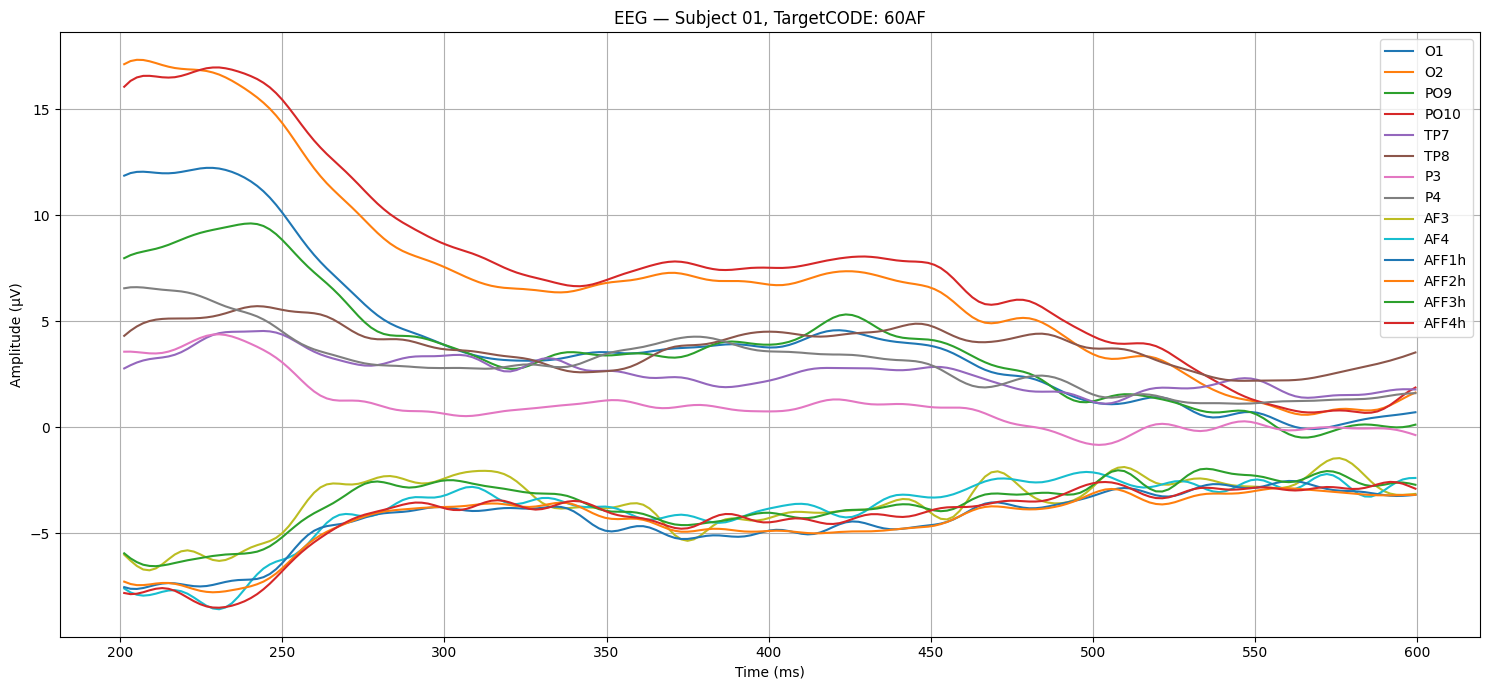

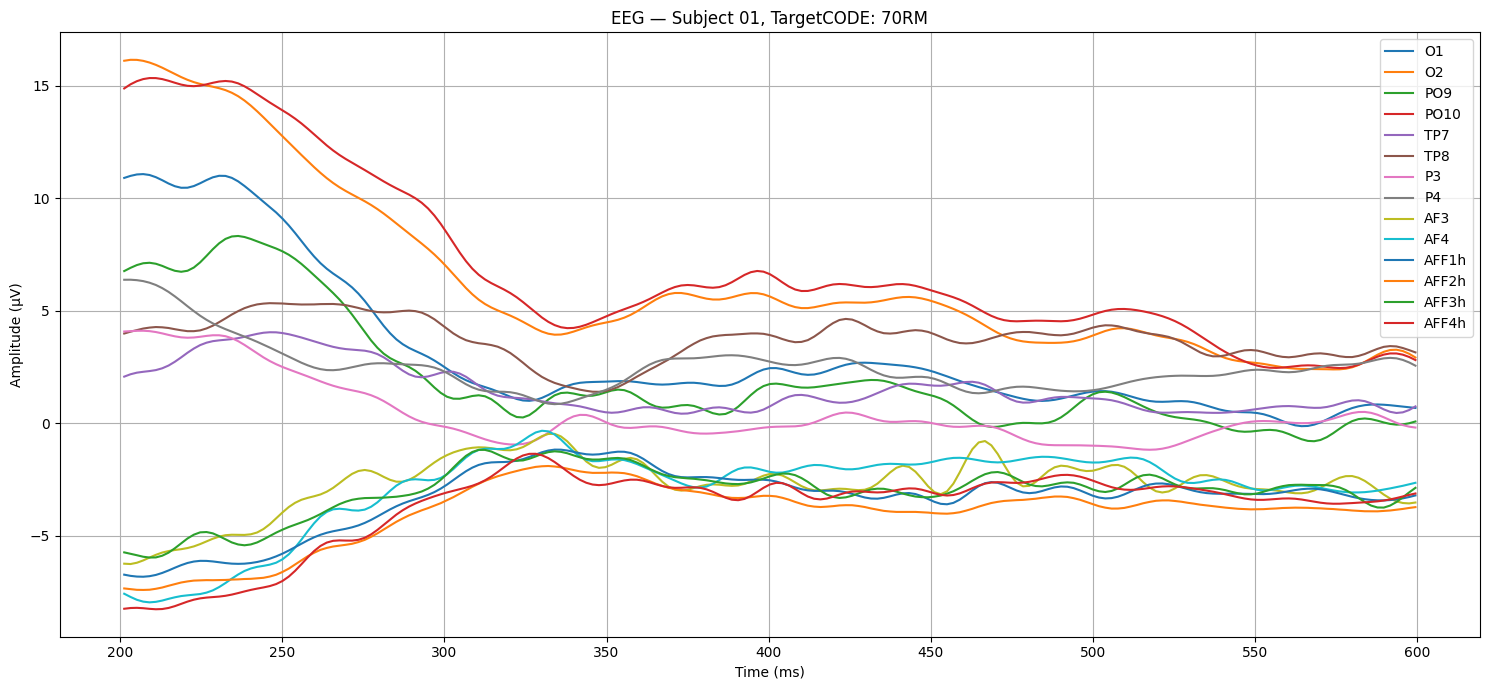

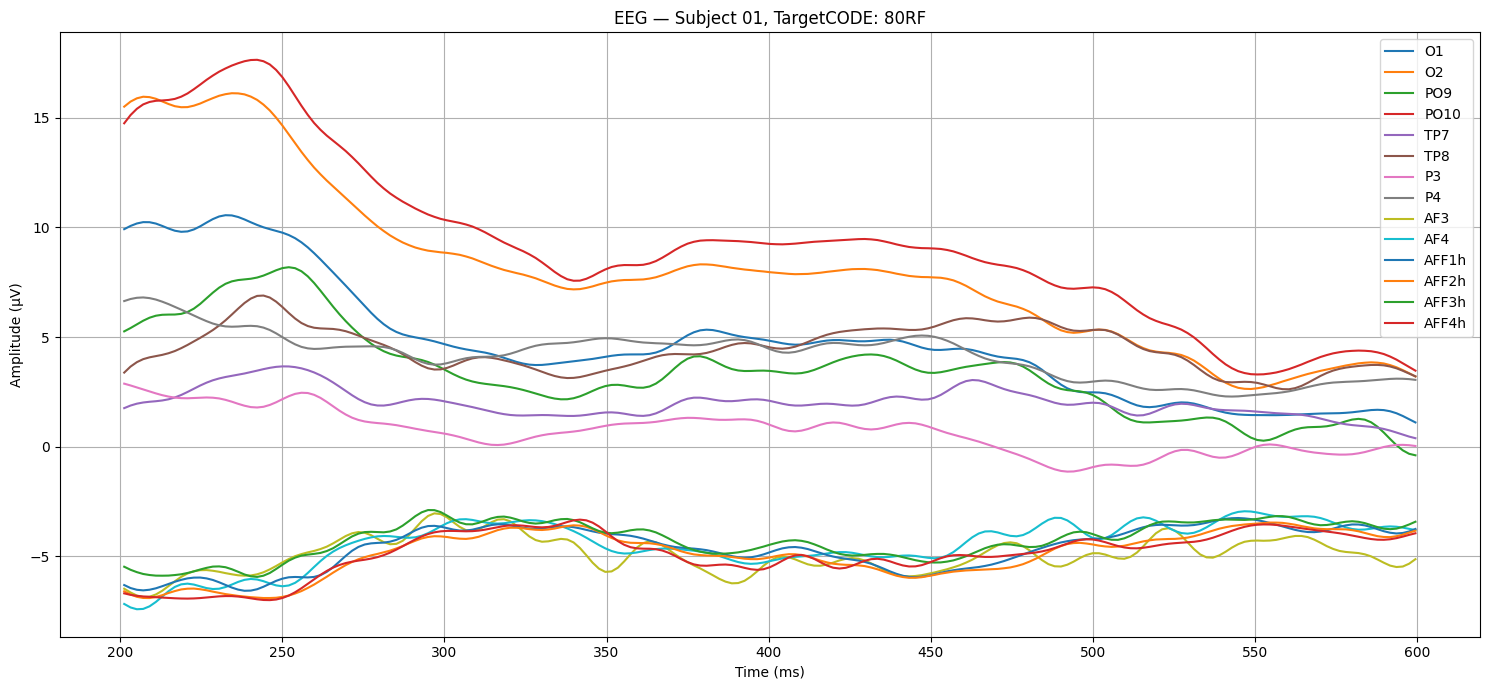

In [7]:
report_sub01 = dataset_filtered[dataset_filtered['SubjectID'] == '01']

for code in report_sub01['TargetCODE'].unique():
    subset = report_sub01[report_sub01['TargetCODE'] == code]
    plt.figure(figsize=(15, 7))
    for channel in EEG_CHANNELS:
        sns.lineplot(x='Time_ms', y=channel, data=subset, label=channel)
    plt.title(f'EEG — Subject 01, TargetCODE: {code}')
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude (μV)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [8]:
print(dataset_filtered['SubjectID'].value_counts().sort_index())

dataset_filtered.to_parquet(PARQUET_PATH)
print(f"Dataset saved to {PARQUET_PATH}  |  shape: {dataset_filtered.shape}")

SubjectID
01    615
02    820
04    820
05    820
06    820
07    820
08    820
09    820
10    820
11    820
12    820
13    820
15    820
16    820
17    820
18    820
19    820
20    820
21    820
22    820
25    820
26    820
27    820
28    820
29    820
30    820
Name: count, dtype: int64
Dataset saved to ../data/file_parquet/dataset_eeg_completo.parquet  |  shape: (21115, 24)


## 5. Filtering & Epoch Construction

### Temporal Cleaning

Per-epoch pipeline:
1. 4th-order Butterworth low-pass filter (cut-off 40 Hz)
2. Linear detrend (removes slow drift)
3. First samples baseline subtraction (first 25 samples ≈ 50 ms)

In [9]:
def apply_temporal_cleaning(epoch_data):
    nyq      = 0.5 * S_FREQ
    b, a     = signal.butter(4, 40.0 / nyq, btype='low')
    filtered = signal.filtfilt(b, a, epoch_data, axis=0)
    cleaned  = signal.detrend(filtered, axis=0)
    baseline_window = cleaned[:25, :]
    return cleaned - np.mean(baseline_window, axis=0)

### Epoch Builder

Groups `dataset_filtered` by `(SubjectID, TargetCODE)`, applies temporal cleaning to EEG
and PCA components, enforces exactly `TARGET_EPOCH_SAMPLES` time points, and rejects
epochs where max amplitude per channel exceeds `ARTIFACT_THRESHOLD_UV` with tolerance of `MAX_BAD_CHANNELS` of channels per epoch

In [10]:
EEG_list         = []
PCA_list         = []
y_list           = []
sub_list         = []
subject_sex_list = []

min_samples = max(int(0.05 * S_FREQ), 16)

for (sub_id, trig), group in dataset_filtered.groupby(['SubjectID', 'TargetCODE']):
    group = group.sort_values('Time_ms')
    if len(group) < min_samples:
        continue

    cleaned_eeg = apply_temporal_cleaning(group[EEG_CHANNELS].values)
    cleaned_pca = apply_temporal_cleaning(group[PCA_COLUMNS].values)

    if cleaned_eeg.shape[0] > TARGET_EPOCH_SAMPLES:
        cleaned_eeg = cleaned_eeg[:TARGET_EPOCH_SAMPLES, :]
    elif cleaned_eeg.shape[0] < TARGET_EPOCH_SAMPLES:
        continue

    if cleaned_pca.shape[0] > TARGET_EPOCH_SAMPLES:
        cleaned_pca = cleaned_pca[:TARGET_EPOCH_SAMPLES, :]
    elif cleaned_pca.shape[0] < TARGET_EPOCH_SAMPLES:
        continue

    channel_max = np.max(np.abs(cleaned_eeg), axis=0)
    if np.sum(channel_max > ARTIFACT_THRESHOLD_UV) > MAX_BAD_CHANNELS:
        continue

    EEG_list.append(cleaned_eeg.T)
    PCA_list.append(cleaned_pca.T)
    y_list.append(group['TargetCODE'].iloc[0])
    sub_list.append(sub_id)
    subject_sex_list.append(group['SubjectSEX'].iloc[0])

print(f"Epochs built: {len(EEG_list)}")

Epochs built: 103


## 6. Tensor Construction

Stack EEG + PCA + sex channel into a 3-D NumPy tensor of shape `(n_epochs, n_channels, n_times)`.
The sex channel is a constant row equal to the `SubjectSEX` value for that epoch.
The tensor is saved to disk so downstream sections (ML, DL) can reload it independently.

In [11]:
combined_X = []
for j in range(len(EEG_list)):
    sex_val = 1.0 if y_list[j].endswith('F') else 0.0
    sex_channel = np.full((1, EEG_list[j].shape[1]), sex_val)
    epoch       = np.vstack((EEG_list[j], PCA_list[j], sex_channel))
    combined_X.append(epoch)

X_final        = np.array(combined_X, dtype=np.float64)
y_final        = np.array(y_list)
subjects_final = np.array(sub_list)

print(f"Tensor shape : {X_final.shape}  [Epochs × Channels × Time]")
print(f"Labels       : {dict(zip(*np.unique(y_final, return_counts=True)))}")

np.savez(TENSOR_PATH, x=X_final, y=y_final, subjects=subjects_final)
print(f"Saved to {TENSOR_PATH}")

Tensor shape : (103, 19, 205)  [Epochs × Channels × Time]
Labels       : {np.str_('50AM'): np.int64(25), np.str_('60AF'): np.int64(26), np.str_('70RM'): np.int64(26), np.str_('80RF'): np.int64(26)}
Saved to ../data/file_tensor/final_tensor.npz


## 7. Encoding / Decoding

### Setup: Z-score Normalization & Flat Channel Removal

Before any model is fitted, two cleaning steps are applied directly to the tensor.

**Z-score normalisation** is computed independently for each epoch and each channel along the time axis, transforming every channel's timeseries to have zero mean and unit standard deviation.

**Flat channel removal** then discards all channels whose mean temporal variance across epochs falls below `VAR_THRESHOLD` (1e-6). These channels carry no discriminative information and would otherwise introduce undefined F-statistics in the ANOVA and degenerate regression weights in the encoding model.

In [12]:
n_epochs, n_channels, n_times_full = X_final.shape

X_norm = zscore(X_final, axis=2)
X_norm[np.isnan(X_norm)] = 0

channel_var = X_final.var(axis=2).mean(axis=0)
good_ch     = np.where(channel_var > VAR_THRESHOLD)[0]
bad_ch      = np.where(channel_var <= VAR_THRESHOLD)[0]
X_clean     = X_norm[:, good_ch, :]
n_good      = len(good_ch)
print(f"Good channels: {n_good}/{n_channels}  |  Excluded: {bad_ch.tolist()}")

Good channels: 18/19  |  Excluded: [18]


### ANOVA F-Map

A **mass univariate ANOVA** is then computed independently at every point in the `[channel × time]` space. At each location, EEG amplitudes are split into two groups by class label and a one-way F-statistic is derived. The output `f_map_full` has shape `(n_good_channels, n_times)` and represents the raw spatiotemporal sensitivity of the EEG signal to the AI vs. Real contrast before any temporal restriction.

In [13]:
label_map = {
    '50AM': 'AI',
    '60AF': 'AI',
    '70RM': 'Real',
    '80RF': 'Real',
}
y_labels = y_final.copy()
y_labels = np.array([label_map[lbl] for lbl in y_labels])

unique_labels = np.unique(y_labels)
n_classes     = len(unique_labels)
f_map_full    = np.zeros((n_good, n_times_full))

for c in range(n_good):
    for t in range(n_times_full):
        groups    = [X_clean[y_labels == lbl, c, t] for lbl in unique_labels]
        f_stat, _ = f_oneway(*groups)
        f_map_full[c, t] = f_stat if np.isfinite(f_stat) else 0

### Time Window Selection (N250 + P300)

Rather than feeding the entire 200–600 ms epoch into the model — which would produce a feature space far larger than the number of available epochs — the analysis is restricted to the two ERP components of theoretical interest:

- **N250** (220–290 ms): a negative deflection over occipito-temporal channels associated with visual object individuation and face identity processing
- **P300 / LPP** (280–500 ms): a broad positive component over centro-parietal channels linked to categorical decision-making and working memory updating


In [14]:
ms_per_tp = (TIME_END_MS - TIME_START_MS) / n_times_full

def ms_to_tp(ms):
    return int((ms - TIME_START_MS) / ms_per_tp)

t_start = ms_to_tp(N250_START)
t_end   = min(n_times_full, ms_to_tp(P300_END))

X_clean = X_clean[:, :, t_start:t_end]
f_map   = f_map_full[:, t_start:t_end]
n_times = X_clean.shape[2]

TIME_WIN_START = N250_START
TIME_WIN_END   = P300_END
time_axis      = np.linspace(TIME_WIN_START, TIME_WIN_END, n_times)
ext            = [TIME_WIN_START, TIME_WIN_END, n_good, 0]

print(f"N250   : {N250_START}–{N250_END} ms")
print(f"P300   : {P300_START}–{P300_END} ms")
print(f"Window : {TIME_WIN_START}–{TIME_WIN_END} ms  →  {n_times} timepoints  "
      f"({ms_per_tp:.2f} ms/tp)")

N250   : 220–290 ms
P300   : 280–500 ms
Window : 220–500 ms  →  143 timepoints  (1.95 ms/tp)


### Encoding

This block contains three sub-steps that together constitute the encoding model.

**STA per class.** For each class, all epochs belonging to that label are averaged, producing a `(n_channels, n_times)` matrix — the condition-averaged EEG response. This is the EEG analogue of the Spike-Triggered Average: instead of averaging the stimulus before each spike, the neural response following each stimulus presentation is averaged. The STA serves as a visual sanity check that the preprocessing has preserved a real neural signal before any model is fitted.

**Ridge encoding model.** Stimulus labels are converted into a one-hot design matrix `S` of shape `(n_epochs, 2)`. A Ridge regression then fits `Y = S · K + ε`, learning a weight matrix `K` that maps each class to its expected spatiotemporal EEG pattern. L2 regularisation is essential because the number of features (channels × timepoints) greatly exceeds the number of epochs; without it the model would memorise noise. `RidgeCV` automatically selects the best regularisation strength from `RIDGE_ALPHAS`. After fitting, `K` is reshaped to `(n_classes, n_channels, n_times)` — one weight map per class.

**Cross-validated R² per channel.** The encoding model is re-fitted independently per channel using 5-fold cross-validation to obtain an honest out-of-sample estimate of performance. A variance-weighted R² is computed from predictions stacked across folds. Negative R² values indicate that the model generalises worse than a trivial mean predictor, the primary diagnostic for insufficient sample size relative to feature dimensionality.

In [15]:
sta = {lbl: np.mean(X_clean[y_labels == lbl], axis=0) for lbl in unique_labels}

ohe    = OneHotEncoder(sparse_output=False)
S      = ohe.fit_transform(y_labels.reshape(-1, 1))
Y_enc = X_clean.reshape(n_epochs, -1)

ridge    = RidgeCV(alphas=RIDGE_ALPHAS, cv=N_SPLITS)
ridge.fit(S, Y_enc)
K        = ridge.coef_.T.reshape(n_classes, n_good, n_times)
R2_train = r2_score(Y_enc, ridge.predict(S), multioutput='variance_weighted')
print(f"Best alpha: {ridge.alpha_:.3f}  |  Training R²: {R2_train:.4f}")

kf    = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
r2_cv = np.zeros(n_good)
for ch in range(n_good):
    y_ch = X_clean[:, ch, :]
    preds, trues = [], []
    for tr, te in kf.split(S):
        m = RidgeCV(alphas=RIDGE_ALPHAS)
        m.fit(S[tr], y_ch[tr])
        preds.append(m.predict(S[te]))
        trues.append(y_ch[te])
    r2_cv[ch] = r2_score(np.vstack(trues), np.vstack(preds), multioutput='variance_weighted')

Best alpha: 100.000  |  Training R²: 0.0052


### Decoding

This block contains two complementary decoding steps.

**AUC discriminability map.** For each class, a one-vs-rest binary label vector is constructed and the Area Under the ROC Curve (AUC) is computed between that vector and the raw EEG amplitude at every `[channel × timepoint]` location. This measure is distribution-free and robust to the non-normality that often characterises single-trial EEG.

**Logistic regression decoding.** A logistic regression classifier with cross-validated L2 regularisation is trained on the flattened EEG tensor and evaluated using `GroupKFold`, which ensures that all epochs from a given subject remain entirely within one side of the train/test split. Accuracy is compared against a chance level of 0.50 for the binary classification.

In [16]:
auc_map = np.zeros((n_classes, n_good, n_times))
for cls_idx, lbl in enumerate(unique_labels):
    y_bin = (y_labels == lbl).astype(int)
    for c in range(n_good):
        for t in range(n_times):
            try:
                auc_map[cls_idx, c, t] = roc_auc_score(y_bin, X_clean[:, c, t])
            except Exception:
                auc_map[cls_idx, c, t] = 0.5

X_2d   = X_clean.reshape(n_epochs, -1)
clf    = LogisticRegressionCV(cv=N_SPLITS, max_iter=1000, random_state=42)
gkf    = GroupKFold(n_splits=N_SPLITS)
scores = cross_val_score(clf, X_2d, y_labels, cv=gkf, groups=subjects_final)
chance = 1 / n_classes
print(f"Decoding accuracy: {scores.mean():.3f} ± {scores.std():.3f}  "
      f"(chance = {chance:.2f})")

Decoding accuracy: 0.623 ± 0.106  (chance = 0.50)


### Plot of the results

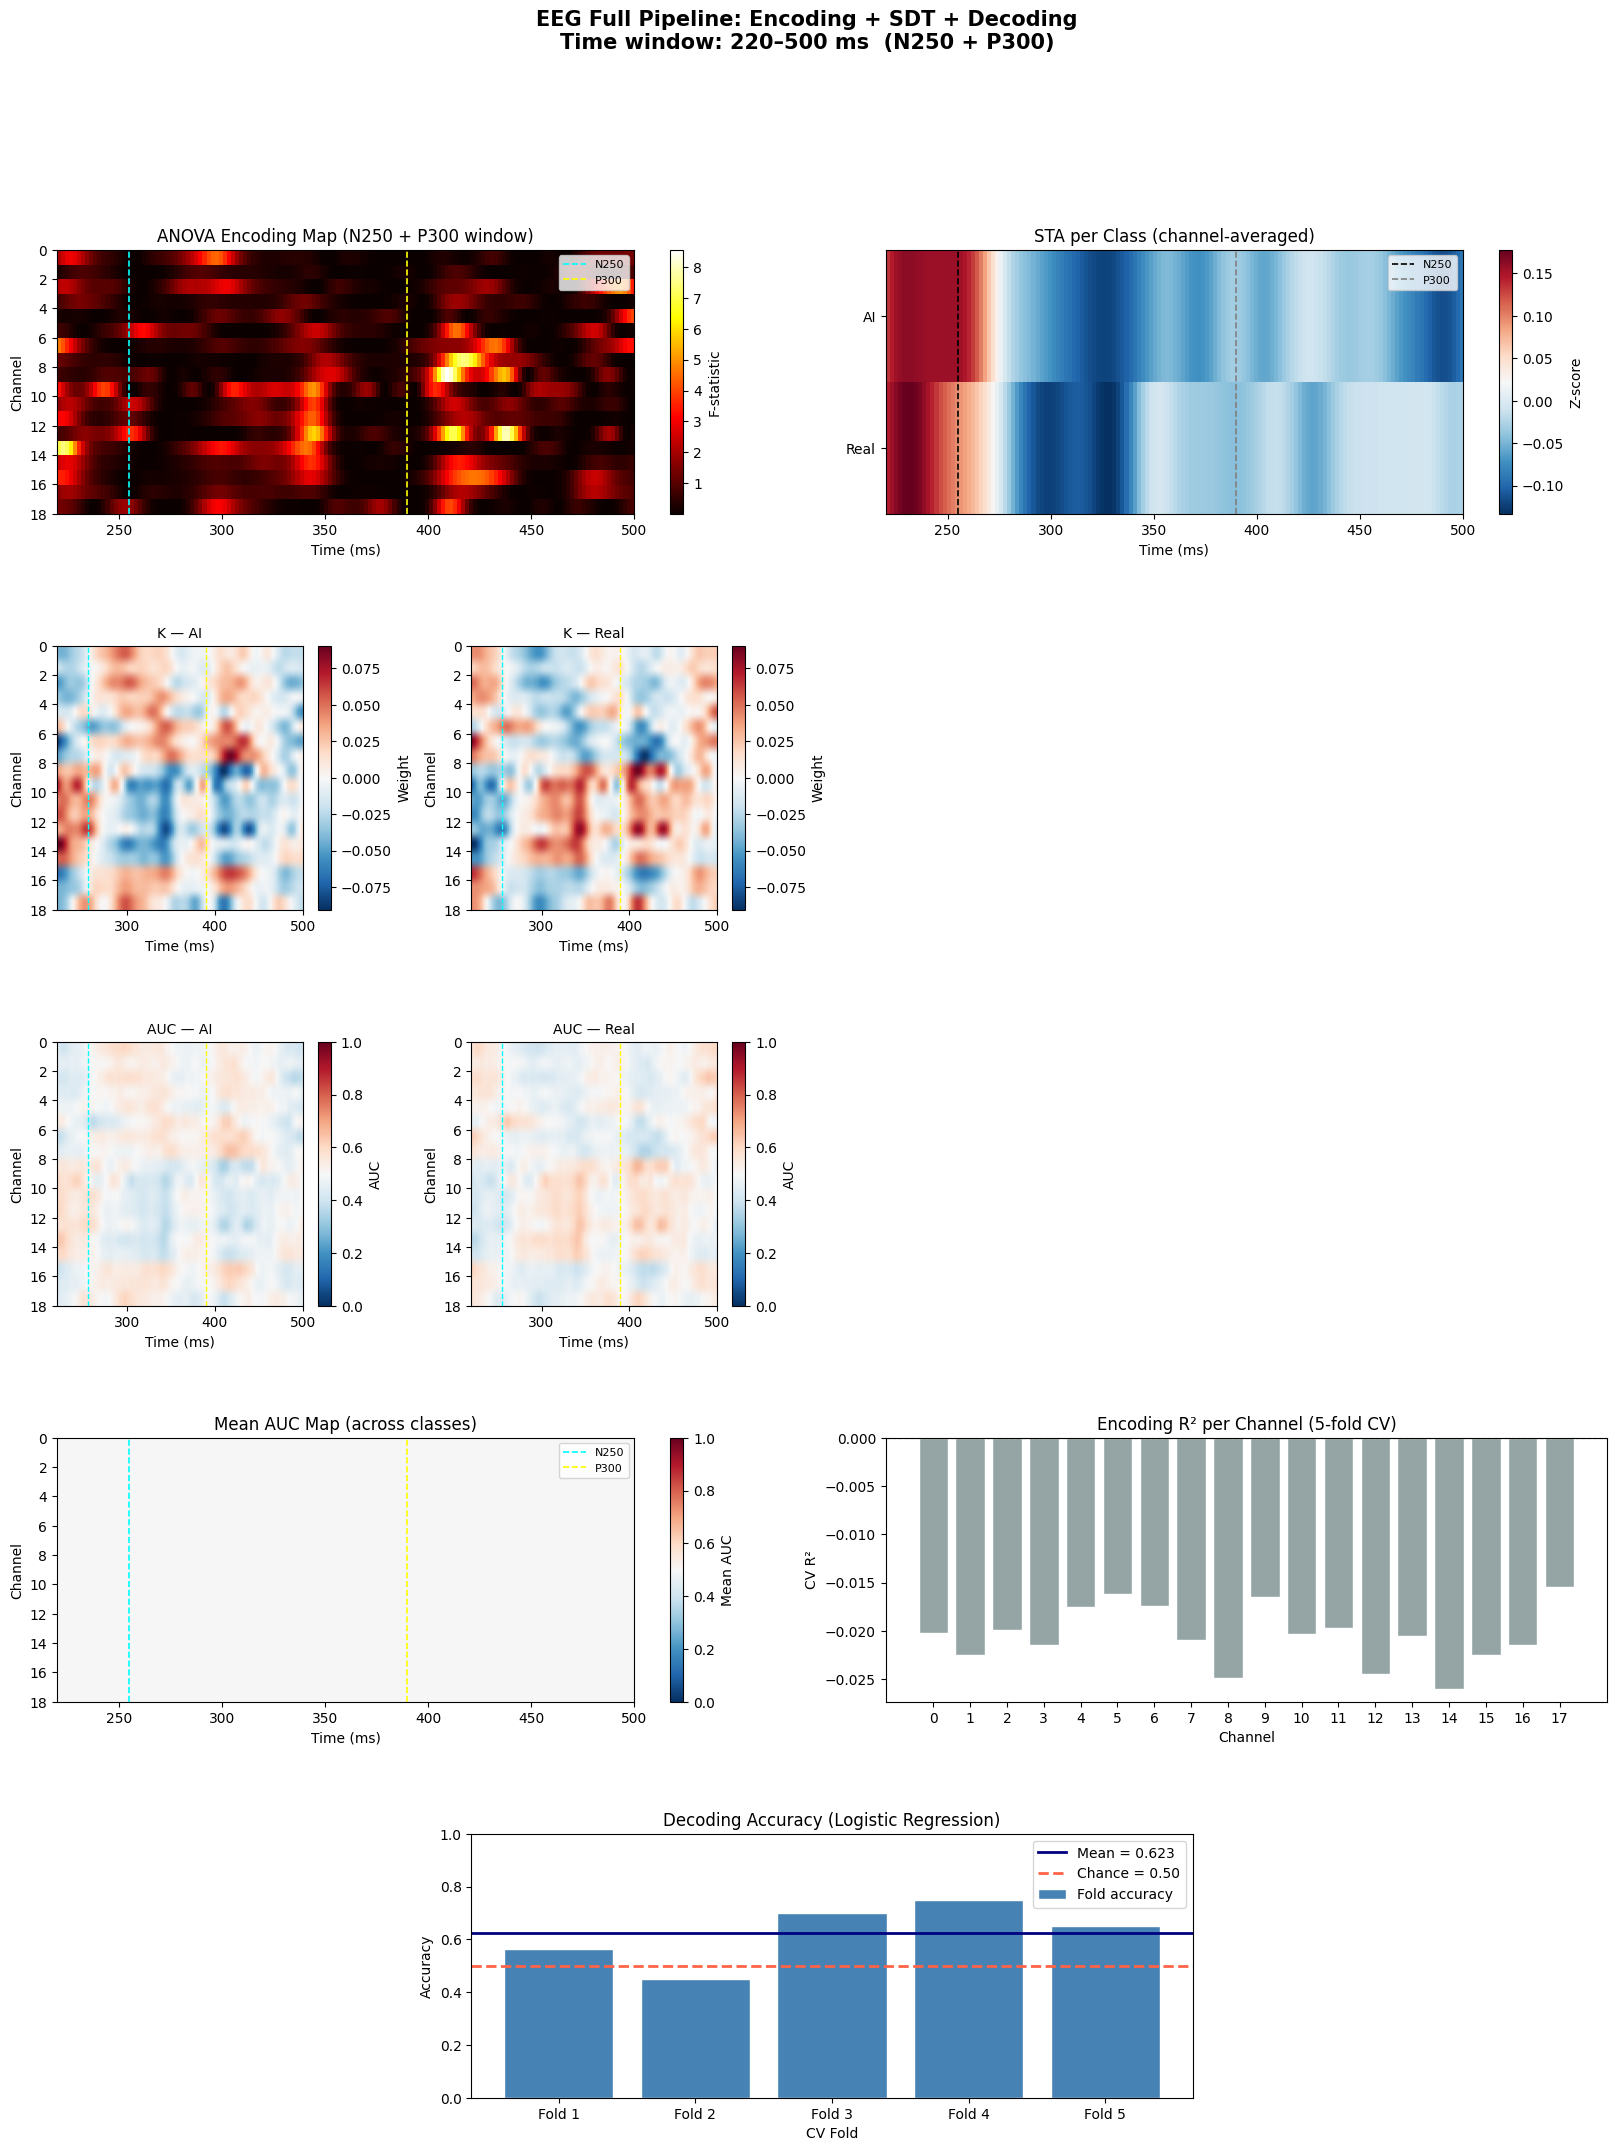

In [17]:
n250_peak_ms = (N250_START + N250_END) / 2
p300_peak_ms = (P300_START + P300_END) / 2

fig = plt.figure(figsize=(20, 24))
fig.suptitle('EEG Full Pipeline: Encoding + SDT + Decoding\n'
             f'Time window: {TIME_WIN_START}–{TIME_WIN_END} ms  (N250 + P300)',
             fontsize=15, fontweight='bold')
gs  = fig.add_gridspec(5, 4, hspace=0.5, wspace=0.35)

ax = fig.add_subplot(gs[0, :2])
im = ax.imshow(f_map, aspect='auto', cmap='hot', extent=ext)
plt.colorbar(im, ax=ax, label='F-statistic')
ax.axvline(n250_peak_ms, color='cyan',   linewidth=1.2, linestyle='--', label='N250')
ax.axvline(p300_peak_ms, color='yellow', linewidth=1.2, linestyle='--', label='P300')
ax.legend(fontsize=8, loc='upper right')
ax.set_title('ANOVA Encoding Map (N250 + P300 window)')
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Channel')

ax = fig.add_subplot(gs[0, 2:])
sta_mat = np.array([sta[lbl].mean(axis=0) for lbl in unique_labels])
im = ax.imshow(sta_mat, aspect='auto', cmap='RdBu_r',
               extent=[TIME_WIN_START, TIME_WIN_END, n_classes, 0])
plt.colorbar(im, ax=ax, label='Z-score')
ax.set_yticks(np.arange(n_classes) + 0.5)
ax.set_yticklabels(unique_labels)
ax.axvline(n250_peak_ms, color='black', linewidth=1.2, linestyle='--', label='N250')
ax.axvline(p300_peak_ms, color='grey',  linewidth=1.2, linestyle='--', label='P300')
ax.legend(fontsize=8, loc='upper right')
ax.set_title('STA per Class (channel-averaged)')
ax.set_xlabel('Time (ms)')

for i, lbl in enumerate(unique_labels):
    ax   = fig.add_subplot(gs[1, i])
    vmax = np.abs(K[i]).max()
    im   = ax.imshow(K[i], aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax, extent=ext)
    plt.colorbar(im, ax=ax, label='Weight')
    ax.axvline(n250_peak_ms, color='cyan',   linewidth=1, linestyle='--')
    ax.axvline(p300_peak_ms, color='yellow', linewidth=1, linestyle='--')
    ax.set_title(f'K — {lbl}', fontsize=10)
    ax.set_xlabel('Time (ms)'); ax.set_ylabel('Channel')

for i, lbl in enumerate(unique_labels):
    ax = fig.add_subplot(gs[2, i])
    im = ax.imshow(auc_map[i], aspect='auto', cmap='RdBu_r', vmin=0, vmax=1, extent=ext)
    plt.colorbar(im, ax=ax, label='AUC')
    ax.axvline(n250_peak_ms, color='cyan',   linewidth=1, linestyle='--')
    ax.axvline(p300_peak_ms, color='yellow', linewidth=1, linestyle='--')
    ax.set_title(f'AUC — {lbl}', fontsize=10)
    ax.set_xlabel('Time (ms)'); ax.set_ylabel('Channel')

ax = fig.add_subplot(gs[3, :2])
im = ax.imshow(auc_map.mean(axis=0), aspect='auto', cmap='RdBu_r', vmin=0, vmax=1, extent=ext)
plt.colorbar(im, ax=ax, label='Mean AUC')
ax.axvline(n250_peak_ms, color='cyan',   linewidth=1.2, linestyle='--', label='N250')
ax.axvline(p300_peak_ms, color='yellow', linewidth=1.2, linestyle='--', label='P300')
ax.legend(fontsize=8, loc='upper right')
ax.set_title('Mean AUC Map (across classes)')
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Channel')

ax = fig.add_subplot(gs[3, 2:])
colors = ['#e74c3c' if r > 0 else '#95a5a6' for r in r2_cv]
ax.bar(np.arange(n_good), r2_cv, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Channel'); ax.set_ylabel('CV R²')
ax.set_title(f'Encoding R² per Channel ({N_SPLITS}-fold CV)')
ax.set_xticks(np.arange(n_good))

ax = fig.add_subplot(gs[4, 1:3])
ax.bar(np.arange(N_SPLITS), scores, color='steelblue', edgecolor='white', label='Fold accuracy')
ax.axhline(scores.mean(), color='navy',   linestyle='-',  linewidth=2,
           label=f'Mean = {scores.mean():.3f}')
ax.axhline(chance,        color='tomato', linestyle='--', linewidth=2,
           label=f'Chance = {chance:.2f}')
ax.set_ylim(0, 1)
ax.set_xlabel('CV Fold'); ax.set_ylabel('Accuracy')
ax.set_title('Decoding Accuracy (Logistic Regression)')
ax.set_xticks(np.arange(N_SPLITS))
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_SPLITS)])
ax.legend()
plt.show()

In [18]:
print("\n" + "=" * 55)
print("SUMMARY")
print("=" * 55)
print(f"  Data shape           : {X_final.shape}  [Epochs × Channels × Time]")
print(f"  Good channels        : {n_good}/{n_channels}")
print(f"  Time window          : {TIME_WIN_START}–{TIME_WIN_END} ms  "
      f"({n_times} timepoints,  {ms_per_tp:.2f} ms/tp)")
print(f"  Classes              : {list(unique_labels)}")
print(f"  Encoding weights K   : {K.shape}  [Classes × Channels × Time]")
print(f"  Best alpha (Ridge)   : {ridge.alpha_:.1f}")
print(f"  Best ANOVA ch        : ch={np.argmax(f_map.max(axis=1))}  "
      f"peak F={f_map.max():.2f}")
print(f"  Best CV R² channel   : ch={np.argmax(r2_cv)}  R²={r2_cv.max():.4f}")
print(f"  Best mean AUC ch     : ch={np.argmax(auc_map.mean(axis=0).max(axis=1))}  "
      f"AUC={auc_map.mean(axis=0).max():.3f}")
print(f"  Decoding accuracy    : {scores.mean():.3f} ± {scores.std():.3f}  "
      f"(chance = {chance:.2f})")


SUMMARY
  Data shape           : (103, 19, 205)  [Epochs × Channels × Time]
  Good channels        : 18/19
  Time window          : 220–500 ms  (143 timepoints,  1.95 ms/tp)
  Classes              : [np.str_('AI'), np.str_('Real')]
  Encoding weights K   : (2, 18, 143)  [Classes × Channels × Time]
  Best alpha (Ridge)   : 100.0
  Best ANOVA ch        : ch=8  peak F=8.57
  Best CV R² channel   : ch=17  R²=-0.0155
  Best mean AUC ch     : ch=1  AUC=0.500
  Decoding accuracy    : 0.623 ± 0.106  (chance = 0.50)


## 8. Machine Learning

**Objective.** Determine whether a Machine Learning classifier can distinguish, from EEG, trials evoked by **real** faces vs **AI-generated (GAN)** faces, a comparison in which human observers are near or below chance level. Decoding **above chance** would demonstrate that the brain *encodes* the difference even when behaviour does not report it.

**Spatial representation (frame-by-frame + majority voting).** Each time point of a trial is treated as an independent spatial sample (18-channel topography): the matrix goes from `(trials, channels, time)` to `(trials·time, channels)`. At test time, predictions for individual time points are aggregated at the trial level by **majority vote** (probability = mean). The big advantage of this approach is the reduced dimensionality (18 features → low overfitting risk with few subjects).

**Pipeline (summary):**
1. **Preprocessing**: intra-subject z-score · 200–600 ms window · decimation ×2 · spatial flatten.
2. **Models**: 8 models in leakage-safe pipelines with randomised tuning: 7 classifiers (LDA-shrinkage, linear SVM plain and calibrated, LogReg-L1, LogReg-ElasticNet, SGD, XGBoost) plus a Dummy chance baseline.
3. **Evaluation**: repeated group-aware nested CV · pooled metrics · permutation test vs chance · Wilcoxon.

### Helper Functions

In [19]:
from sklearn.base import BaseEstimator, TransformerMixin


class IntraSubjectZScore(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=float)
        ids, feats = X[:, 0], X[:, 1:].copy()
        for s in np.unique(ids):
            m = ids == s
            mu = feats[m].mean(axis=0)
            sd = feats[m].std(axis=0)
            sd = np.where(sd == 0.0, 1.0, sd)
            feats[m] = (feats[m] - mu) / sd
        return feats


def decimate_to_odd(X, factor):
    Xd = np.asarray(X)[:, :, ::factor]
    if Xd.shape[2] % 2 == 0:
        Xd = Xd[:, :, :-1]
    return Xd


def spatial_flatten(X, y, subjects):
    X = np.asarray(X)
    n_trials, n_channels, n_tp = X.shape
    X_flat       = X.transpose(0, 2, 1).reshape(-1, n_channels)
    y_flat       = np.repeat(np.asarray(y), n_tp)
    subjects_flat = np.repeat(np.asarray(subjects), n_tp)
    trial_ids    = np.repeat(np.arange(n_trials), n_tp)
    return X_flat, y_flat, subjects_flat, trial_ids


def aggregate_trials(y_pred_tp, y_score_tp, y_true_tp, trial_ids):
    y_pred_tp  = np.asarray(y_pred_tp)
    y_score_tp = np.asarray(y_score_tp)
    y_true_tp  = np.asarray(y_true_tp)
    trial_ids  = np.asarray(trial_ids)
    y_true, y_pred, y_score = [], [], []
    for t_id in np.unique(trial_ids):
        m = trial_ids == t_id
        y_true.append(y_true_tp[m][0])
        vote, _ = mode(y_pred_tp[m], keepdims=False)
        y_pred.append(vote)
        y_score.append(y_score_tp[m].mean())
    return np.array(y_true), np.array(y_pred), np.array(y_score)


def groups_disjoint(train_groups, test_groups):
    return len(set(np.asarray(train_groups).tolist()) &
               set(np.asarray(test_groups).tolist())) == 0


def permute_trial_labels(y_tp, trial_ids, rng):
    y_tp      = np.asarray(y_tp)
    trial_ids = np.asarray(trial_ids)
    uniq = np.unique(trial_ids)
    trial_label = np.array([y_tp[trial_ids == t][0] for t in uniq])
    permuted    = trial_label[rng.permutation(len(uniq))]
    mapping     = dict(zip(uniq.tolist(), permuted))
    return np.array([mapping[t] for t in trial_ids.tolist()])


def summarize_selected_params(param_dicts):
    keys = set()
    for d in param_dicts:
        keys.update(d.keys())
    summary = {}
    for key in sorted(keys):
        counts = Counter()
        for d in param_dicts:
            if key not in d:
                continue
            value = d[key]
            label = (type(value).__name__
                     if hasattr(value, 'get_params') and
                     not isinstance(value, (int, float, str, bool))
                     else value)
            counts[label] += 1
        summary[key] = counts.most_common()
    return summary


def representative_params(param_dicts):
    def is_number(v):
        return (isinstance(v, (int, float, np.integer, np.floating))
                and not isinstance(v, bool))
    def all_int(vals):
        return all(isinstance(v, (int, np.integer)) and not isinstance(v, bool)
                   for v in vals)
    def signature(v):
        if hasattr(v, 'get_params') and not isinstance(v, (int, float, str, bool)):
            return type(v).__name__
        return v
    keys = set().union(*(d.keys() for d in param_dicts)) if param_dicts else set()
    rep = {}
    for key in keys:
        vals = [d[key] for d in param_dicts if key in d]
        if vals and all(is_number(v) for v in vals):
            med = np.median(vals)
            rep[key] = int(round(med)) if all_int(vals) else float(med)
        else:
            top_sig = Counter(signature(v) for v in vals).most_common(1)[0][0]
            rep[key] = next(v for v in vals if signature(v) == top_sig)
    return rep


def permutation_p_value(observed, null_distribution):
    null = np.asarray(null_distribution, dtype=float)
    return (np.sum(null >= observed) + 1) / (null.size + 1)


print('Helper functions defined.')

Helper functions defined.


### Preprocessing

- **Subject exclusion** `01`: dropped before the binary comparison because one of its four condition-averaged ERPs is missing (no `50AM` trace), leaving the subject without a complete set of conditions. The remaining subjects are kept.
- **Intra-subject z-score** (per channel, over all time points of the subject). ERP amplitude varies between individuals, individuals have a difeerent baseline, so normalising *per subject* prevents the model from learning physiological identity instead of the task. Because CV splits are **per subject**, the transform never mixes train and test.
- **200–600 ms window**: the window suggested by the project, containing the late relevant components (N250, P300, LP/PN400) visible in the ERPs.
- **Decimation ×2** (205 → 103 time points). The signal is low-pass filtered at 40 Hz but sampled at 512 Hz: by Nyquist ~80 Hz would suffice, so adjacent samples are nearly redundant. Halves the computational cost with negligible loss; the **odd** number of time points makes a tie in the binary majority vote impossible.
- **Channels**: 14 EEG (suggested electrodes: `O1, O2, PO9, PO10, TP7, TP8, P3, P4, AF3, AF4, AFF1h–4h`) + 4 **regional PCA** components (compressing variance from non-selected electrodes). The constant *sex* channel is removed: it is zeroed by z-score, is not informative for AI-vs-Real (sex is balanced between classes by design) and generated NaN values in `f_classif`.

In [20]:
_data        = np.load(TENSOR_PATH, allow_pickle=True)
X_ml_raw     = _data['x']
y_ml_codes   = _data['y']
subjects_ml  = _data['subjects']
print('Tensor loaded:', X_ml_raw.shape,
      '| classes:', dict(zip(*np.unique(y_ml_codes, return_counts=True))))

EXCLUDE = {'01', 1}
keep = ~np.isin(subjects_ml, list(EXCLUDE))
X_ml_raw, y_ml_codes, subjects_ml = (
    X_ml_raw[keep], y_ml_codes[keep], subjects_ml[keep])


if X_ml_raw.shape[1] == 19:
    X_ml_raw = X_ml_raw[:, :18, :]

# 0 = AI (50AM, 60AF)   1 = Real (70RM, 80RF)
y_ml = np.where(np.isin(y_ml_codes, ['50AM', '60AF']), 0, 1)


DECIMATION_FACTOR = 2
X_ml_dec = decimate_to_odd(X_ml_raw, DECIMATION_FACTOR)

X_flat, y_flat, subjects_flat, trial_ids = spatial_flatten(
    X_ml_dec, y_ml, subjects_ml)


_, _subj_codes = np.unique(subjects_flat, return_inverse=True)
X_flat = np.column_stack([_subj_codes.astype(float), X_flat])

print(f'Subjects       : {len(np.unique(subjects_ml))}')
print(f'Trials         : {X_ml_dec.shape[0]}  | timepoints/trial: {X_ml_dec.shape[2]}')
print(f'Design matrix  : {X_flat.shape}  '
      f'(rows = trial x tp | col 0 = subject id, cols 1.. = {X_flat.shape[1]-1} channels)')
print(f'Class balance  : {np.bincount(y_ml)}  (0=AI, 1=Real)')

Tensor loaded: (103, 19, 205) | classes: {np.str_('50AM'): np.int64(25), np.str_('60AF'): np.int64(26), np.str_('70RM'): np.int64(26), np.str_('80RF'): np.int64(26)}
Subjects       : 25
Trials         : 100  | timepoints/trial: 103
Design matrix  : (10300, 19)  (rows = trial x tp | col 0 = subject id, cols 1.. = 18 channels)
Class balance  : [50 50]  (0=AI, 1=Real)


### Models: two-stage hyperparameter search

All models share the **same leakage-safe pipeline**, re-fitted *inside every CV fold*:

`scaler → VarianceThreshold → SelectKBest(ANOVA-F, k ∈ {5,10,15,all}) → classifier`

Feature selection **inside the fold** (never on the full dataset) avoids target leakage. Varying `k` echoes the accuracy-vs-number-of-electrodes analysis of **Leoni et al. 2019**.

**Pipeline and search choices.**

1. **The scaler is a hyperparameter: `passthrough` (none), `MinMaxScaler`, `RobustScaler`.** Preprocessing already applies the **intra-subject z-score** (a standardisation), so including `StandardScaler` in the search would be **redundant**: instead the search chooses among *no additional scaler* (`passthrough`), MinMax or Robust. SVM and LogReg remain sensitive to absolute scale (which interacts with `C`), so we let the search decide; each choice is re-fitted only on the training fold (leakage-safe).
2. **Calibrated margin classifiers.** Added `LinearSVC_Cal` = `CalibratedClassifierCV(LinearSVC, sigmoid)` alongside plain `LinearSVC` (so the notebook *shows* the comparison). Calibration refits the base estimator on multiple inner folds → more robust ensemble and real `predict_proba` for AUC.
3. **Targeted ranges + larger budget.** `C` concentrated on the 2–3 useful decades (not spread over 5 → fewer wasted samples), optional `class_weight` also where previously fixed, `n_iter` 40–60/model.

**Stage 2 (see section below): dedicated search on the winner.** Once the best model is identified, `get_focused_grid()` launches a **wider and finer search on its parameters only** (wider decades, extra axes such as `loss`/calibration `method`, `n_iter` ~150), re-evaluated with the *same* group-aware nested CV: no optimism because the model *family* is fixed and the enriched search stays confined to the inner loop.

| Model | Motivation |
|---|---|
| **LDA** | Standard MVPA/EEG decoding reference |
| **LinearSVC** / **LinearSVC_Cal** | Plain vs calibrated linear SVM (direct comparison) |
| **LogReg-L1**, **LogReg-ElasticNet** | Regularised/sparse linear models, interpretable |
| **SGDClassifier** | Scalable gradient descent |
| **XGBoost** | Gradient boosting with per-channel importance |
| **DummyClassifier** | Chance baseline: validates metrics and permutation test |

In [21]:
CALIB_CV = 3


def safe_mcc(y_true, y_pred):
    if len(np.unique(y_pred)) <= 1:
        return 0.0
    return matthews_corrcoef(y_true, y_pred)


acc_scorer = make_scorer(accuracy_score)


def _pipe(clf):
    return Pipeline([
        ('subjz',    IntraSubjectZScore()),
        ('scaler',   StandardScaler()),
        ('variance', VarianceThreshold(threshold=0.0)),
        ('selector', SelectKBest(score_func=f_classif)),
        ('clf',      clf),
    ])


def _cal(estimator, method='sigmoid'):
    """Wraps a margin classifier in CalibratedClassifierCV."""
    return CalibratedClassifierCV(estimator, method=method, cv=CALIB_CV)


def get_models_and_grids():
    """Stage 1 — 8 models; every grid includes `scaler` and `selector__k`."""
    return [
        ('LDA', _pipe(LinearDiscriminantAnalysis(solver='lsqr')),
         {'clf__shrinkage': ['auto', 0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
          'scaler': SCALER_CHOICES,
          'selector__k': K_CANDIDATES}, 40),


        ('LinearSVC', _pipe(LinearSVC(dual='auto', max_iter=5000, random_state=RANDOM_STATE)),
         {'clf__C': loguniform(1e-2, 3e1),
          'clf__class_weight': [None, 'balanced'],
          'scaler': SCALER_CHOICES,
          'selector__k': K_CANDIDATES}, 45),


        ('LinearSVC_Cal',
         _pipe(_cal(LinearSVC(dual='auto', max_iter=5000, random_state=RANDOM_STATE))),
         {'clf__estimator__C': loguniform(5e-2, 2e1),
          'clf__estimator__class_weight': [None, 'balanced'],
          'scaler': SCALER_CHOICES,
          'selector__k': K_CANDIDATES}, 45),

#        ('SVC_RBF', _pipe(SVC(kernel='rbf', cache_size=500, probability=False,
#                              random_state=RANDOM_STATE)),
#         {'clf__C': loguniform(1e-1, 1e2),
#          'clf__gamma': loguniform(1e-4, 1e0),
#          'clf__class_weight': [None, 'balanced'],
#          'scaler': SCALER_CHOICES,
#          'selector__k': K_CANDIDATES}, 60),

        ('LogReg_L1', _pipe(LogisticRegression(solver='saga', penalty='l1',
                                               max_iter=5000, random_state=RANDOM_STATE)),
         {'clf__C': loguniform(1e-2, 1e1),
          'clf__class_weight': [None, 'balanced'],
          'scaler': SCALER_CHOICES,
          'selector__k': K_CANDIDATES}, 45),

        ('LogReg_EN', _pipe(LogisticRegression(solver='saga', penalty='elasticnet',
                                               max_iter=5000, random_state=RANDOM_STATE)),
         {'clf__C': loguniform(1e-2, 1e1),
          'clf__l1_ratio': uniform(0.0, 1.0),
          'clf__class_weight': [None, 'balanced'],
          'scaler': SCALER_CHOICES,
          'selector__k': K_CANDIDATES}, 60),

        ('SGD', _pipe(SGDClassifier(max_iter=2000, tol=1e-3, random_state=RANDOM_STATE)),
         {'clf__loss': ['hinge', 'log_loss', 'modified_huber'],
          'clf__penalty': ['l1', 'l2', 'elasticnet'],
          'clf__alpha': loguniform(1e-5, 1e-1),
          'clf__l1_ratio': uniform(0.0, 1.0),
          'clf__class_weight': [None, 'balanced'],
          'scaler': SCALER_CHOICES,
          'selector__k': K_CANDIDATES}, 60),

#        ('RandomForest', _pipe(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
#         {'clf__n_estimators': randint(150, 600),
#          'clf__max_depth': [2, 3, 4, 5, None],
#          'clf__min_samples_leaf': randint(1, 8),
#          'clf__max_features': ['sqrt', 'log2', None],
#          'clf__class_weight': ['balanced', 'balanced_subsample'],
#          'scaler': SCALER_CHOICES,
#          'selector__k': K_CANDIDATES}, 60),

        ('XGBoost', _pipe(XGBClassifier(eval_metric='logloss', tree_method='hist',
                                        random_state=RANDOM_STATE, n_jobs=1)),
         {'clf__n_estimators': randint(100, 400),
          'clf__max_depth': randint(2, 6),
          'clf__learning_rate': loguniform(1e-2, 3e-1),
          'clf__subsample': uniform(0.6, 0.4),
          'clf__colsample_bytree': uniform(0.5, 0.5),
          'clf__gamma': uniform(0.0, 5.0),
          'clf__reg_lambda': loguniform(1e-2, 1e1),
          'scaler': SCALER_CHOICES,
          'selector__k': K_CANDIDATES}, 60),

        ('Dummy', _pipe(DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)),
         {'clf__strategy': ['stratified', 'most_frequent', 'uniform', 'prior']}, 4),
    ]


def get_focused_grid(name):
    s = SCALER_CHOICES
    k = K_CANDIDATES
    grids = {
        'LDA': ({'clf__shrinkage': ['auto', None] + list(np.round(np.linspace(0, 1, 21), 3)),
                 'clf__solver': ['lsqr', 'eigen'],
                 'scaler': s, 'selector__k': k}, 80),

        'LinearSVC': ({'clf__C': loguniform(1e-3, 1e2),
                       'clf__loss': ['hinge', 'squared_hinge'],
                       'clf__class_weight': [None, 'balanced'],
                       'scaler': s, 'selector__k': k}, 150),

        'LinearSVC_Cal': ({'clf__estimator__C': loguniform(1e-3, 1e2),
                           'clf__estimator__loss': ['hinge', 'squared_hinge'],
                           'clf__estimator__class_weight': [None, 'balanced'],
                           'clf__method': ['sigmoid', 'isotonic'],
                           'scaler': s, 'selector__k': k}, 150),

#        'SVC_RBF': ({'clf__C': loguniform(1e-2, 1e3),
#                     'clf__gamma': loguniform(1e-5, 1e1),
#                     'clf__class_weight': [None, 'balanced'],
#                     'scaler': s, 'selector__k': k}, 150),

        'LogReg_L1': ({'clf__C': loguniform(1e-3, 1e2),
                       'clf__class_weight': [None, 'balanced'],
                       'scaler': s, 'selector__k': k}, 120),

        'LogReg_EN': ({'clf__C': loguniform(1e-3, 1e2),
                       'clf__l1_ratio': uniform(0.0, 1.0),
                       'clf__class_weight': [None, 'balanced'],
                       'scaler': s, 'selector__k': k}, 150),

        'SGD': ({'clf__loss': ['hinge', 'log_loss', 'modified_huber', 'squared_hinge'],
                 'clf__penalty': ['l1', 'l2', 'elasticnet'],
                 'clf__alpha': loguniform(1e-6, 1e0),
                 'clf__l1_ratio': uniform(0.0, 1.0),
                 'clf__class_weight': [None, 'balanced'],
                 'scaler': s, 'selector__k': k}, 150),

#        'RandomForest': ({'clf__n_estimators': randint(100, 800),
#                          'clf__max_depth': [2, 3, 4, 5, 6, 8, None],
#                          'clf__min_samples_leaf': randint(1, 12),
#                          'clf__min_samples_split': randint(2, 12),
#                          'clf__max_features': ['sqrt', 'log2', None, 0.5],
#                          'clf__class_weight': [None, 'balanced', 'balanced_subsample'],
#                          'scaler': s, 'selector__k': k}, 150),

        'XGBoost': ({'clf__n_estimators': randint(100, 600),
                     'clf__max_depth': randint(2, 8),
                     'clf__learning_rate': loguniform(5e-3, 3e-1),
                     'clf__subsample': uniform(0.5, 0.5),
                     'clf__colsample_bytree': uniform(0.4, 0.6),
                     'clf__gamma': uniform(0.0, 6.0),
                     'clf__reg_lambda': loguniform(1e-2, 1e2),
                     'clf__reg_alpha': loguniform(1e-3, 1e1),
                     'clf__min_child_weight': randint(1, 8),
                     'scaler': s, 'selector__k': k}, 150),

        'Dummy': ({'clf__strategy': ['stratified', 'most_frequent', 'uniform', 'prior']}, 4),
    }
    return grids[name]


MODELS = get_models_and_grids()
print(f"{len(MODELS)} models configured:", [m[0] for m in MODELS])
print("Scalers searched:",
      [sc if isinstance(sc, str) else type(sc).__name__ for sc in SCALER_CHOICES])

8 models configured: ['LDA', 'LinearSVC', 'LinearSVC_Cal', 'LogReg_L1', 'LogReg_EN', 'SGD', 'XGBoost', 'Dummy']
Scalers searched: ['passthrough', 'MinMaxScaler', 'RobustScaler']


## Evaluation

- **Repeated group-aware nested CV.** Outer = `StratifiedGroupKFold(5)` × 5 repetitions = **25 outer estimates**. Inner = `GroupShuffleSplit(5, 20%)` for tuning. Nested CV separates hyperparameter selection from the generalisation estimate. `groups=subjects` everywhere — verified by `groups_disjoint()` at every fold.
- **Pooled metrics.** With 4 trials/subject, per-fold accuracies are coarse (25% jumps); trial-level predictions are **accumulated** for global ROC and CM.
- **Permutation test vs chance** *(primary claim)*. Labels permuted **at the trial level** (~1000 times); p = `(#{null ≥ obs} + 1) / (N + 1)` (Phipson & Smyth, 2010). Answers *"does the brain distinguish AI from Real above chance?"*
- **Wilcoxon + Bonferroni** *(secondary)* on the 25 per-fold accuracies. Overlapping training sets → slightly anti-conservative (Nadeau & Bengio, 2003).

**Runtime:** full config = several hours. `QUICK_TEST = True` → ~1 minute.

In [22]:
QUICK_TEST      = False
N_OUTER_FOLDS   = 5
N_OUTER_REPEATS = 5
N_INNER_SPLITS  = 5
INNER_TEST_SIZE = 0.20
N_PERMUTATIONS  = 1000
if QUICK_TEST:
    N_OUTER_FOLDS, N_OUTER_REPEATS, N_INNER_SPLITS, N_PERMUTATIONS = 2, 1, 3, 50



def get_scores(model, X):
    if hasattr(model, 'predict_proba'):
        try:
            return model.predict_proba(X)[:, 1]
        except Exception:
            pass++
    if hasattr(model, 'decision_function'):
        try:
            return model.decision_function(X)
        except Exception:
            pass
    return model.predict(X).astype(float)


def safe_auc(y_true, y_score):
    return roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else 0.5


inner_cv = GroupShuffleSplit(n_splits=N_INNER_SPLITS, test_size=INNER_TEST_SIZE,
                              random_state=RANDOM_STATE)


def run_nested_cv(models, collect_params=False, verbose=True):
    results, pooled, chosen = {}, {}, {}
    for name, pipeline, param_dist, n_iter in models:
        if QUICK_TEST:
            n_iter = min(n_iter, 3)
        t0 = time.time()
        fm = {k: [] for k in ['acc', 'bacc', 'f1', 'mcc', 'auc']}
        p_true, p_pred, p_score = [], [], []
        params_per_fold = []

        for rep in range(N_OUTER_REPEATS):
            outer_cv = StratifiedGroupKFold(n_splits=N_OUTER_FOLDS, shuffle=True,
                                            random_state=RANDOM_STATE + rep)
            for tr, te in outer_cv.split(X_flat, y_flat, groups=subjects_flat):
                assert groups_disjoint(subjects_flat[tr], subjects_flat[te])
                search = RandomizedSearchCV(
                    pipeline, param_dist, n_iter=n_iter,
                    scoring=acc_scorer, cv=inner_cv, n_jobs=-1,
                    random_state=RANDOM_STATE, error_score=np.nan
                )
                search.fit(X_flat[tr], y_flat[tr], groups=subjects_flat[tr])
                best = search.best_estimator_
                if collect_params:
                    params_per_fold.append(search.best_params_)
                yt, yp, ys = aggregate_trials(
                    best.predict(X_flat[te]),
                    get_scores(best, X_flat[te]),
                    y_flat[te], trial_ids[te]
                )
                fm['acc'].append(accuracy_score(yt, yp))
                fm['bacc'].append(balanced_accuracy_score(yt, yp))
                fm['f1'].append(f1_score(yt, yp, average='macro'))
                fm['mcc'].append(safe_mcc(yt, yp))
                fm['auc'].append(safe_auc(yt, ys))
                p_true += yt.tolist(); p_pred += yp.tolist(); p_score += ys.tolist()

        results[name] = {k: np.array(v) for k, v in fm.items()}
        pooled[name]  = (np.array(p_true), np.array(p_pred), np.array(p_score))
        chosen[name]  = params_per_fold
        if verbose:
            print(f"  {name:14s} ACC {np.nanmean(results[name]['acc']):.3f}"
                  f" (var {np.nanvar(results[name]['acc']):.4f})"
                  f"  F1 {np.nanmean(results[name]['f1']):.3f}"
                  f"  AUC {np.nanmean(results[name]['auc']):.3f}"
                  f"  [{time.time()-t0:.0f}s]")

    if collect_params:
        return results, pooled, chosen
    return results, pooled


print(f"Nested CV: outer {N_OUTER_FOLDS}x{N_OUTER_REPEATS} StratifiedGroupKFold | "
      f"inner GroupShuffleSplit({N_INNER_SPLITS}, test={INNER_TEST_SIZE})")
results, pooled = run_nested_cv(MODELS)

Nested CV: outer 5x5 StratifiedGroupKFold | inner GroupShuffleSplit(5, test=0.2)
  LDA            ACC 0.700 (var 0.0048)  F1 0.698  AUC 0.783  [39s]
  LinearSVC      ACC 0.696 (var 0.0070)  F1 0.695  AUC 0.778  [41s]
  LinearSVC_Cal  ACC 0.700 (var 0.0062)  F1 0.698  AUC 0.778  [80s]
  LogReg_L1      ACC 0.694 (var 0.0075)  F1 0.692  AUC 0.778  [72s]
  LogReg_EN      ACC 0.696 (var 0.0054)  F1 0.694  AUC 0.777  [107s]
  SGD            ACC 0.688 (var 0.0099)  F1 0.678  AUC 0.778  [93s]
  XGBoost        ACC 0.678 (var 0.0092)  F1 0.673  AUC 0.774  [531s]
  Dummy          ACC 0.500 (var 0.0000)  F1 0.333  AUC 0.500  [7s]


In [23]:
order     = sorted(results, key=lambda n: -np.nanmean(results[n]['acc']))
best_name = order[0]


def _fmt(r, k):
    return f"{np.nanmean(r[k]):.3f} (var {np.nanvar(r[k]):.4f})"


report_df = pd.DataFrame(
    [{'Model': n, 'ACC': _fmt(results[n], 'acc'),
      'macro-F1': _fmt(results[n], 'f1'),
      'ROC-AUC': _fmt(results[n], 'auc')} for n in order]
).set_index('Model')

n_folds = len(results[best_name]['acc'])
print(f"Trial-level performance (mean and variance over {n_folds} outer folds):")
try:
    from IPython.display import display
    display(report_df)
except Exception:
    print(report_df)
print(f"\nBest model by mean accuracy: {best_name}")

Trial-level performance (mean and variance over 25 outer folds):


,ACC,macro-F1,ROC-AUC
Model,,,
LDA,0.700 (var 0.0048),0.698 (var 0.0048),0.783 (var 0.0090)
LinearSVC_Cal,0.700 (var 0.0062),0.698 (var 0.0064),0.778 (var 0.0098)
LinearSVC,0.696 (var 0.0070),0.695 (var 0.0070),0.778 (var 0.0107)
LogReg_EN,0.696 (var 0.0054),0.694 (var 0.0055),0.777 (var 0.0097)
LogReg_L1,0.694 (var 0.0075),0.692 (var 0.0076),0.778 (var 0.0121)
SGD,0.688 (var 0.0099),0.678 (var 0.0126),0.778 (var 0.0131)
XGBoost,0.678 (var 0.0092),0.673 (var 0.0101),0.774 (var 0.0122)
Dummy,0.500 (var 0.0000),0.333 (var 0.0000),0.500 (var 0.0000)



Best model by mean accuracy: LDA


## Stage 2: focused search on the winning model

Stage 1 selected the best model by exploring *all* classifiers over broad but necessarily diffuse grids (a few dozen samples spread across many axes). Now that the **family** is fixed, it makes sense to spend the search budget *entirely on it*: `get_focused_grid(best_name)` widens the decades, adds previously fixed axes and raises `n_iter` to ~150.

**Why this is not cheating.** The enriched search stays confined to the **inner loop** of the *same* group-aware nested CV: every outer estimate still sees only subjects never used for tuning. We are refining the **hyperparameters** of an already chosen family, not re-selecting the family on the test — so the estimate remains honest. We adopt the focused configuration only if mean accuracy does not worsen, and report the **most frequently chosen configuration** across folds (the one that would be deployed).

In [24]:
MODELS_BY_NAME = {m[0]: m for m in MODELS}

focused_dist, focused_niter = get_focused_grid(best_name)
winner_pipeline = MODELS_BY_NAME[best_name][1]
focused_models  = [(best_name, winner_pipeline, focused_dist, focused_niter)]

eff_niter = min(focused_niter, 3) if QUICK_TEST else focused_niter
print(f"Stage 2: focused search on '{best_name}' (n_iter={eff_niter}, "
      f"{N_OUTER_FOLDS}x{N_OUTER_REPEATS} outer folds):")
res_focus, pool_focus, chosen_focus = run_nested_cv(focused_models, collect_params=True)

def _row(tag, r):
    return {'Search': tag,
            'ACC': f"{np.nanmean(r['acc']):.3f} (var {np.nanvar(r['acc']):.4f})",
            'macro-F1': f"{np.nanmean(r['f1']):.3f}",
            'ROC-AUC': f"{np.nanmean(r['auc']):.3f}"}

acc1, acc2 = np.nanmean(results[best_name]['acc']), np.nanmean(res_focus[best_name]['acc'])
cmp_df = pd.DataFrame([_row('Stage 1 ', results[best_name]),
                       _row('Stage 2 ', res_focus[best_name])]).set_index('Search')
try:
    from IPython.display import display
    display(cmp_df)
except Exception:
    print(cmp_df)

# Adopt focused config only if it doesn't worsen mean accuracy.
if acc2 >= acc1:
    results[best_name], pooled[best_name] = res_focus[best_name], pool_focus[best_name]
    FINAL_GRID, FINAL_NITER = focused_dist, focused_niter
    print("  => adopted")
else:
    FINAL_GRID, FINAL_NITER = MODELS_BY_NAME[best_name][2], MODELS_BY_NAME[best_name][3]
    print("  => not adopted")
FINAL_PIPELINE = winner_pipeline

# Most frequently chosen config across folds
summary = summarize_selected_params(chosen_focus[best_name])
print(f"\nMost frequently chosen hyperparameters from focused search on {best_name} "
      f"(over {len(chosen_focus[best_name])} folds):")
for param, counts in summary.items():
    top = ", ".join(f"{val}x{cnt}" for val, cnt in counts[:3])
    print(f"  {param:28s} {top}")

Stage 2: focused search on 'LDA' (n_iter=80, 5x5 outer folds):
  LDA            ACC 0.720 (var 0.0062)  F1 0.718  AUC 0.780  [58s]


,ACC,macro-F1,ROC-AUC
Search,,,
Stage 1,0.700 (var 0.0048),0.698,0.783
Stage 2,0.720 (var 0.0062),0.718,0.780


  => adopted

Most frequently chosen hyperparameters from focused search on LDA (over 25 folds):
  clf__shrinkage               0.05x9, 0.2x4, 0.15x3
  clf__solver                  lsqrx15, eigenx10
  scaler                       RobustScalerx10, passthroughx8, MinMaxScalerx7
  selector__k                  10x15, 15x6, 5x3


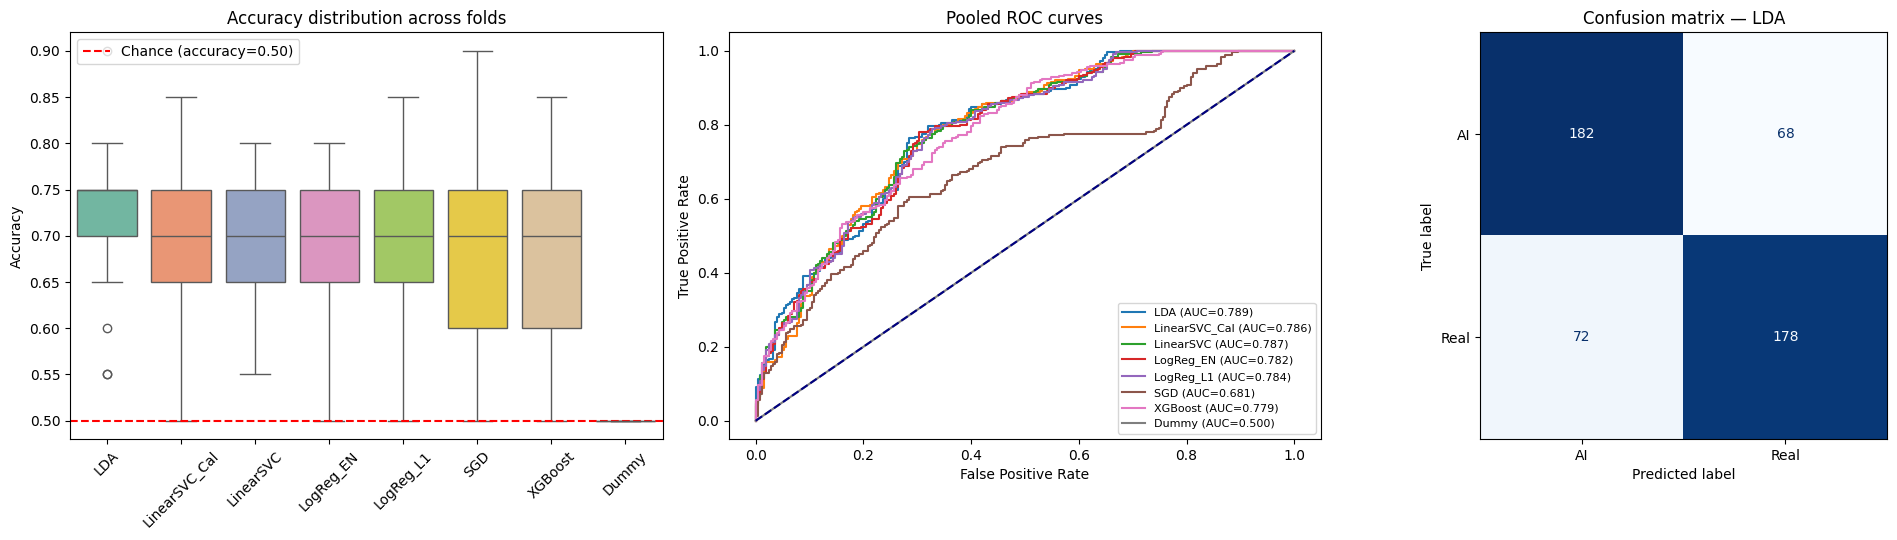

Chart saved: spatial_pipeline_performance.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

box_df = pd.DataFrame({n: results[n]['acc'] for n in order})
sns.boxplot(data=box_df, ax=axes[0], palette='Set2')
axes[0].axhline(0.5, color='red', ls='--', label='Chance (accuracy=0.50)')
axes[0].set_title('Accuracy distribution across folds')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

for n in order:
    yt, yp, ys = pooled[n]
    if len(np.unique(yt)) > 1:
        fpr, tpr, _ = roc_curve(yt, ys)
        axes[1].plot(fpr, tpr, label=f"{n} (AUC={auc(fpr, tpr):.3f})")
axes[1].plot([0, 1], [0, 1], 'navy', ls='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Pooled ROC curves')
axes[1].legend(loc='lower right', fontsize=8)

yt, yp, _ = pooled[best_name]
ConfusionMatrixDisplay(
    confusion_matrix(yt, yp), display_labels=['AI', 'Real']
).plot(cmap='Blues', ax=axes[2], colorbar=False)
axes[2].set_title(f'Confusion matrix — {best_name}')

plt.tight_layout()
plt.savefig('spatial_pipeline_performance.png', dpi=200)
plt.show()
print("Chart saved: spatial_pipeline_performance.png")

### Statistical significance testing

Two complementary tests assess whether the decoding is genuinely above chance.

**Permutation test vs chance (primary claim).** The final tuned pipeline of the winning model is refitted across an outer `StratifiedGroupKFold`, trial-level predictions are pooled, and the observed accuracy and MCC are compared against a null distribution built by permuting the labels **at the trial level** (`N_PERMUTATIONS` shuffles, subject groups preserved). The p-value follows Phipson & Smyth (2010): `p = (#{null ≥ observed} + 1) / (N + 1)`. This answers the central question: *does the brain distinguish AI from Real above chance?* and reporting MCC alongside accuracy ensures the effect is not an artefact of class proportions.

**Wilcoxon signed-rank + Bonferroni (secondary).** A two-sided Wilcoxon signed-rank test compares the per-fold accuracies of the best model against each competing model, Bonferroni-corrected for the multiple comparisons, to check whether the winner is statistically separable from the alternatives. Because the outer folds share overlapping training sets the test is mildly anti-conservative, so it is treated as secondary, the permutation test carries the main claim.

In [26]:

rep_params = representative_params(chosen_focus[best_name])
best_pipe  = clone(FINAL_PIPELINE).set_params(**rep_params)

print(f"Final config for permutation test ({best_name}) "
      f"[representative over {len(chosen_focus[best_name])} folds]:")
for k in sorted(rep_params):
    v = rep_params[k]
    shown = (type(v).__name__
             if hasattr(v, 'get_params') and not isinstance(v, (int, float, str, bool))
             else v)
    print(f"   {k:28s} {shown}")

perm_cv = StratifiedGroupKFold(n_splits=N_OUTER_FOLDS, shuffle=True,
                                random_state=RANDOM_STATE)


def pooled_trial_preds(estimator, y_target):
    pt, pp = [], []
    for tr, te in perm_cv.split(X_flat, y_target, groups=subjects_flat):
        assert groups_disjoint(subjects_flat[tr], subjects_flat[te])
        est = clone(estimator).fit(X_flat[tr], y_target[tr])
        yt, yp, _ = aggregate_trials(
            est.predict(X_flat[te]), np.zeros(len(te)),
            y_target[te], trial_ids[te]
        )
        pt += yt.tolist(); pp += yp.tolist()
    return np.array(pt), np.array(pp)


obs_t, obs_p = pooled_trial_preds(best_pipe, y_flat)
observed_acc = accuracy_score(obs_t, obs_p)
observed_mcc = safe_mcc(obs_t, obs_p)

rng = np.random.default_rng(RANDOM_STATE)
null_mcc, null_acc = [], []
for _ in range(N_PERMUTATIONS):
    nt, npd = pooled_trial_preds(
        best_pipe, permute_trial_labels(y_flat, trial_ids, rng)
    )
    null_mcc.append(safe_mcc(nt, npd))
    null_acc.append(accuracy_score(nt, npd))
null_mcc, null_acc = np.array(null_mcc), np.array(null_acc)

p_acc = permutation_p_value(observed_acc, null_acc)
p_mcc = permutation_p_value(observed_mcc, null_mcc)

print("=" * 72)
print(f"PERMUTATION TEST vs CHANCE — {best_name}  (n={N_PERMUTATIONS} trial-level shuffles)")
print(f"  Observed accuracy={observed_acc:.3f}  | null={null_acc.mean():.3f}"
      f" (var {null_acc.var():.4f}) | p={p_acc:.4f}   (chance=0.50)")
print(f"  Observed MCC     ={observed_mcc:+.3f} | null={null_mcc.mean():+.3f}"
      f" (var {null_mcc.var():.4f}) | p={p_mcc:.4f}")
print("  => decoding ABOVE chance" if p_acc < 0.05
      else "  => NOT distinguishable from chance")
print("=" * 72)

Final config for permutation test (LDA) [representative over 25 folds]:
   clf__shrinkage               0.05
   clf__solver                  lsqr
   scaler                       RobustScaler
   selector__k                  10
PERMUTATION TEST vs CHANCE — LDA  (n=1000 trial-level shuffles)
  Observed accuracy=0.750  | null=0.491 (var 0.0038) | p=0.0010   (chance=0.50)
  Observed MCC     =+0.500 | null=-0.018 (var 0.0151) | p=0.0010
  => decoding ABOVE chance


In [27]:
print(f"Wilcoxon signed-rank (two-sided) on per-fold accuracy vs {best_name}, "
      f"Bonferroni-corrected:")
best_folds = results[best_name]['acc']
others = [n for n in order if n != best_name]
pvals = []
for n in others:
    a, b = best_folds, results[n]['acc']
    mask = np.isfinite(a) & np.isfinite(b)
    if np.allclose(a[mask], b[mask]):
        p = 1.0
    else:
        try:
            _, p = wilcoxon(a[mask], b[mask], zero_method='zsplit',
                            alternative='two-sided')
        except ValueError:
            p = 1.0
    pvals.append(p)

m = len(pvals)
print(f"{'vs Model':<14}{'p (raw)':>10}{'p (Bonf.)':>12}{'signif.?':>10}")
print("-" * 46)
for n, p in zip(others, pvals):
    pc = min(1.0, p * m)
    print(f"{n:<14}{p:>10.4f}{pc:>12.4f}{('YES' if pc < 0.05 else 'no'):>10}")

print("\nNote: overlapping training sets -> anti-conservative (Nadeau & Bengio, 2003).")

Wilcoxon signed-rank (two-sided) on per-fold accuracy vs LDA, Bonferroni-corrected:
vs Model         p (raw)   p (Bonf.)  signif.?
----------------------------------------------
LinearSVC_Cal     0.0845      0.5915        no
LinearSVC         0.0523      0.3661        no
LogReg_EN         0.0557      0.3898        no
LogReg_L1         0.0394      0.2758        no
SGD               0.0494      0.3460        no
XGBoost           0.0318      0.2226        no
Dummy             0.0000      0.0001       YES

Note: overlapping training sets -> anti-conservative (Nadeau & Bengio, 2003).


## 9. Deep Learning

### Architecture

In [28]:
random.seed(DL_SEED); np.random.seed(DL_SEED); torch.manual_seed(DL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(DL_SEED)
    torch.backends.cudnn.deterministic = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- DATA LOADING ---
_dl         = np.load(TENSOR_PATH, allow_pickle=True)
X_dl        = _dl['x'].astype(np.float32)
y_raw_dl    = _dl['y']
subjects_dl = _dl['subjects']

N_FOLDS_DL = min(len(np.unique(subjects_dl)), 5)
N_INNER_TRIALS = 150

label_map = {"50AM": 0, "60AF": 0, "70RM": 1, "80RF": 1}
y_dl = np.array([label_map.get(l, 0) for l in y_raw_dl], dtype=np.int64)

X_mean_dl = X_dl.mean(axis=(1, 2), keepdims=True)
X_std_dl = X_dl.std(axis=(1, 2), keepdims=True)
X_norm_dl = (X_dl - X_mean_dl) / (X_std_dl + 1e-8)

# --- AUGMENTATION ---
def temporal_jitter(x, max_shift=10):
    return np.roll(x, random.randint(-max_shift, max_shift), axis=-1)

def channel_dropout(x, p_drop=0.15):
    mask = np.random.binomial(1, 1-p_drop, size=(x.shape[0], 1)).astype(np.float32)
    return x * mask

def gaussian_noise(x, sigma=0.04):
    return x + np.random.randn(*x.shape).astype(np.float32) * sigma

def amplitude_scale(x, lo=0.85, hi=1.15):
    return x * random.uniform(lo, hi)

class EEGDataset(Dataset):
    def __init__(self, x, y, augment=False):
        self.x = x.astype(np.float32)
        self.y = y.astype(np.int64)
        self.augment = augment

    def __len__(self): return len(self.x)

    def __getitem__(self, idx):
        w = self.x[idx].copy()
        if self.augment:
            w = temporal_jitter(w)
            w = channel_dropout(w)
            w = gaussian_noise(w)
            w = amplitude_scale(w)
        return torch.from_numpy(w), torch.tensor(self.y[idx])

#ARCHITECTURE: SpatialTemporalCNN (STCNN), Applies a learnable dense spatial filter (19x19 matrix) followed by a 1D temporal convolution. This is a CNN with learned spatial mixing
class SpatialTemporalCNN(nn.Module):
    def __init__(self, channels=19, temp_filters=32, kernel_size=16,
                 n_layers=1, adj_init="identity", adj_norm="sigmoid", dropout=0.4, classes=2):
        super().__init__()
        self.n_layers = n_layers
        self.adj_norm_type = adj_norm

        if adj_init == "uniform": init_w = torch.ones(channels, channels) / channels
        elif adj_init == "identity": init_w = torch.eye(channels)
        else: init_w = torch.randn(channels, channels) * 0.1
        self.adj = nn.Parameter(init_w)

        self.conv1 = nn.Conv1d(channels, temp_filters, kernel_size=kernel_size, padding="same")
        self.bn1 = nn.BatchNorm1d(temp_filters)

        if n_layers == 2:
            self.conv2 = nn.Conv1d(temp_filters, temp_filters, kernel_size=kernel_size, padding="same")
            self.bn2 = nn.BatchNorm1d(temp_filters)
            self.res_proj = nn.Conv1d(channels, temp_filters, kernel_size=1, bias=False)

        self.pool = nn.AdaptiveAvgPool1d(8)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(temp_filters * 8, classes)

    def _apply_spatial_filter(self, x):
        if self.adj_norm_type == "softmax": adj = F.softmax(self.adj, dim=-1)
        elif self.adj_norm_type == "sigmoid": adj = torch.sigmoid(self.adj)
        else: adj = self.adj
        return (x.transpose(1, 2) @ adj).transpose(1, 2)

    def forward(self, x):
        x_s = self._apply_spatial_filter(x)
        out = F.elu(self.bn1(self.conv1(x_s)))
        if self.n_layers == 2:
            residual = self.res_proj(x_s)
            out = F.elu(self.bn2(self.conv2(out)) + residual)
        out = self.pool(out)
        return self.fc(self.dropout(out.flatten(1)))

### Training

In [29]:
!pip install cmaes


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
RUN_OPTUNA_SEARCH = True   # !!!!! Set True only to redo the search from scratch (may take hours and, since the dataset is relatively small,
# the results may vary from those discussed and presented in the report due to statistical fluctuations and the limited sample size).
def reset_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def mixup_batch(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0))
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def mixup_criterion(crit, pred, ya, yb, lam):
    return lam*crit(pred, ya) + (1-lam)*crit(pred, yb)

def build_scheduler(optimizer, scheduler_type, epochs):
    if scheduler_type == 'cosine':
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    elif scheduler_type == 'step':
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs // 3), gamma=0.5)
    return None

def train_one_epoch(model, loader, optimizer, criterion, mixup_alpha=0.2):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        if random.random() < 0.5:
            xm, ya, yb_, lam = mixup_batch(xb, yb, alpha=mixup_alpha)
            loss = mixup_criterion(criterion, model(xm), ya, yb_, lam)
        else:
            loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    tot_loss, total = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        tot_loss += criterion(out, yb).item() * xb.size(0)
        total += xb.size(0)
    return tot_loss / total

@torch.no_grad()
def collect_preds(model, loader):
    model.eval()
    probs, preds, labels = [], [], []
    for xb, yb in loader:
        out = model(xb.to(device))
        probs.extend(F.softmax(out, dim=1)[:,1].cpu().numpy())
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(yb.numpy())
    return np.array(probs), np.array(preds), np.array(labels)

def hp_space(trial):
    return dict(
        temp_filters = trial.suggest_categorical('temp_filters', [16, 32, 64, 128]),
        kernel_size  = trial.suggest_categorical('kernel_size',  [4, 8, 16, 32]),
        n_layers     = trial.suggest_categorical('n_layers',     [1, 2]),
        adj_init     = trial.suggest_categorical('adj_init',     ['uniform','identity','random']),
        adj_norm     = trial.suggest_categorical('adj_norm',     ['none','softmax','sigmoid']),
        dropout      = trial.suggest_float('dropout', 0.1, 0.75),
        lr           = trial.suggest_float('lr',  5e-5, 1e-2, log=True),
        wd           = trial.suggest_float('wd',  1e-6, 5e-3, log=True),
        scheduler    = trial.suggest_categorical('scheduler', ['none','cosine','step']),
        batch_size   = trial.suggest_categorical('batch_size', [8, 16, 32]),
        epochs       = trial.suggest_categorical('epochs',     [60, 80, 100, 120]),
        mixup_alpha  = trial.suggest_float('mixup_alpha', 0.05, 0.4),
    )

def model_factory(hp):
    return SpatialTemporalCNN(
        temp_filters = hp['temp_filters'], kernel_size  = hp['kernel_size'],
        n_layers     = hp['n_layers'], adj_init     = hp['adj_init'],
        adj_norm     = hp['adj_norm'], dropout      = hp['dropout'],
    )

# Initialization
outer_gkf = GroupKFold(n_splits=N_FOLDS_DL)
criterion_gl = nn.CrossEntropyLoss()
outer_accs, fold_aucs = [], []
all_preds, all_labels, all_probs = [], [], []
fold_models = []       # keep every trained model for the aggregated XAI
fold_te_indices = []   # keep the test indices of each fold

# hardcoded_hps = [
#     {'temp_filters': 32, 'kernel_size': 16, 'n_layers': 1, 'adj_init': 'identity', 'adj_norm': 'sigmoid', 'dropout': 0.430385, 'lr': 0.000886, 'wd': 9.445e-06, 'scheduler': 'cosine', 'batch_size': 32, 'epochs': 120, 'mixup_alpha': 0.3743},
#     {'temp_filters': 64, 'kernel_size': 16, 'n_layers': 1, 'adj_init': 'random', 'adj_norm': 'softmax', 'dropout': 0.252020, 'lr': 0.000718, 'wd': 7.672e-05, 'scheduler': 'cosine', 'batch_size': 32, 'epochs': 120, 'mixup_alpha': 0.2786},
#     {'temp_filters': 128, 'kernel_size': 4, 'n_layers': 2, 'adj_init': 'uniform', 'adj_norm': 'softmax', 'dropout': 0.349319, 'lr': 0.000134, 'wd': 0.001161, 'scheduler': 'none', 'batch_size': 32, 'epochs': 60, 'mixup_alpha': 0.0630},
#     {'temp_filters': 32, 'kernel_size': 8, 'n_layers': 1, 'adj_init': 'identity', 'adj_norm': 'sigmoid', 'dropout': 0.395922, 'lr': 0.000453, 'wd': 0.000848, 'scheduler': 'none', 'batch_size': 32, 'epochs': 100, 'mixup_alpha': 0.2787},
#     {'temp_filters': 128, 'kernel_size': 32, 'n_layers': 2, 'adj_init': 'random', 'adj_norm': 'softmax', 'dropout': 0.466126, 'lr': 0.000378, 'wd': 0.000111, 'scheduler': 'none', 'batch_size': 32, 'epochs': 120, 'mixup_alpha': 0.2111}
# ]

hardcoded_hps = [
    {'temp_filters': 16, 'kernel_size': 8, 'n_layers': 1, 'adj_init': 'random', 'adj_norm': 'none', 'dropout': 0.5046571918190736, 'lr': 0.000635896422246323, 'wd': 3.0044116686639446e-06, 'scheduler': 'step', 'batch_size': 32, 'epochs': 120, 'mixup_alpha': 0.3394635362586372},
    {'temp_filters': 64, 'kernel_size': 4, 'n_layers': 2, 'adj_init': 'uniform', 'adj_norm': 'sigmoid', 'dropout': 0.574093238462129, 'lr': 0.0010808703136853898, 'wd': 0.0016946249349555115, 'scheduler': 'step', 'batch_size': 32, 'epochs': 60, 'mixup_alpha': 0.36393300724250593},
    {'temp_filters': 128, 'kernel_size': 32, 'n_layers': 1, 'adj_init': 'uniform', 'adj_norm': 'none', 'dropout': 0.43072365380252486, 'lr': 0.00010052406565475403, 'wd': 7.67457142739357e-06, 'scheduler': 'step', 'batch_size': 32, 'epochs': 80, 'mixup_alpha': 0.35229211045320113},
    {'temp_filters': 32, 'kernel_size': 8, 'n_layers': 2, 'adj_init': 'random', 'adj_norm': 'softmax', 'dropout': 0.5262496137701614, 'lr': 0.003248987393210566, 'wd': 3.2919129849906944e-05, 'scheduler': 'cosine', 'batch_size': 32, 'epochs': 60, 'mixup_alpha': 0.2448754074193164},
    {'temp_filters': 32, 'kernel_size': 4, 'n_layers': 2, 'adj_init': 'uniform', 'adj_norm': 'sigmoid', 'dropout': 0.3422047446607334, 'lr': 0.0007310057721514055, 'wd': 0.00026089115991403613, 'scheduler': 'cosine', 'batch_size': 16, 'epochs': 120, 'mixup_alpha': 0.3490575859172018}
]

if RUN_OPTUNA_SEARCH:
    print("Running SpatialTemporalCNN (STCNN) - Nested CV (this will take a while)...")
else:
    print("Running SpatialTemporalCNN (STCNN) - Fast Mode (using pre-computed hyperparameters)...")

for outer_fold, (outer_tr_idx, outer_te_idx) in enumerate(outer_gkf.split(X_norm_dl, y_dl, groups=subjects_dl)):
    print(f"\n[Fold {outer_fold+1}/{N_FOLDS_DL}]")

    if RUN_OPTUNA_SEARCH:
        def objective(trial):
            hp = hp_space(trial)
            gss = GroupShuffleSplit(n_splits=3, test_size=0.25, random_state=DL_SEED + outer_fold)
            split_losses = []
            for split_i, (lo_tr, lo_val) in enumerate(gss.split(X_norm_dl[outer_tr_idx], y_dl[outer_tr_idx], groups=subjects_dl[outer_tr_idx])):
                i_tr, i_val = outer_tr_idx[lo_tr], outer_tr_idx[lo_val]
                tr_ds = EEGDataset(X_norm_dl[i_tr], y_dl[i_tr], augment=True)
                val_ds = EEGDataset(X_norm_dl[i_val], y_dl[i_val], augment=False)
                dl_drop = True if len(tr_ds) > hp['batch_size'] else False
                tr_dl = DataLoader(tr_ds, batch_size=hp['batch_size'], shuffle=True, drop_last=dl_drop)
                val_dl = DataLoader(val_ds, batch_size=16, shuffle=False)

                reset_all_seeds(DL_SEED + outer_fold * 100 + split_i)
                m = model_factory(hp).to(device)
                opt = torch.optim.Adam(m.parameters(), lr=hp['lr'], weight_decay=hp['wd'])
                sch = build_scheduler(opt, hp['scheduler'], hp['epochs'])

                best_val, patience, max_patience = float('inf'), 0, 20
                for epoch in range(hp['epochs']):
                    train_one_epoch(m, tr_dl, opt, criterion_gl, mixup_alpha=hp['mixup_alpha'])
                    if sch is not None: sch.step()

                    if split_i == 0 and (epoch + 1) % 10 == 0:
                        val_loss = evaluate(m, val_dl, criterion_gl)
                        trial.report(val_loss, step=epoch)
                        if trial.should_prune(): raise optuna.TrialPruned()

                    if (epoch + 1) % 10 == 0:
                        val_loss = evaluate(m, val_dl, criterion_gl)
                        if val_loss < best_val:
                            best_val = val_loss
                            patience = 0
                        else: patience += 1
                        if patience >= max_patience // 10: break

                split_losses.append(evaluate(m, val_dl, criterion_gl))
            return np.mean(split_losses)

        sampler = CmaEsSampler(n_startup_trials=10, seed=DL_SEED + outer_fold, warn_independent_sampling=False)
        pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=20, interval_steps=10)
        study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study.optimize(objective, n_trials=N_INNER_TRIALS, n_jobs=1)
        best_hp = study.best_trial.params
        print(f"  Best HP found: {best_hp}")
    else:
        best_hp = hardcoded_hps[outer_fold]

    reset_all_seeds(DL_SEED + outer_fold * 999)

    model_final = model_factory(best_hp).to(device)
    opt_final = torch.optim.Adam(model_final.parameters(), lr=best_hp['lr'], weight_decay=best_hp['wd'])
    sch_final = build_scheduler(opt_final, best_hp['scheduler'], best_hp['epochs'])

    tr_ds_full = EEGDataset(X_norm_dl[outer_tr_idx], y_dl[outer_tr_idx], augment=True)
    te_ds_full = EEGDataset(X_norm_dl[outer_te_idx], y_dl[outer_te_idx], augment=False)

    drop_l = True if len(tr_ds_full) > best_hp['batch_size'] else False
    tr_dl_full = DataLoader(tr_ds_full, batch_size=best_hp['batch_size'], shuffle=True, drop_last=drop_l)
    te_dl_full = DataLoader(te_ds_full, batch_size=16, shuffle=False)

    for epoch in range(best_hp['epochs']):
        train_one_epoch(model_final, tr_dl_full, opt_final, criterion_gl, mixup_alpha=best_hp['mixup_alpha'])
        if sch_final is not None: sch_final.step()

    fold_models.append(copy.deepcopy(model_final))
    fold_te_indices.append(outer_te_idx)

    probs, preds, labels = collect_preds(model_final, te_dl_full)
    acc = accuracy_score(labels, preds)
    try: fold_auc = roc_auc_score(labels, probs)
    except ValueError: fold_auc = 0.5

    outer_accs.append(acc)
    fold_aucs.append(fold_auc)
    all_probs.extend(probs)
    all_preds.extend(preds)
    all_labels.extend(labels)

    print(f"  --> Acc: {acc*100:.1f}% | AUC: {fold_auc:.3f}")


Running SpatialTemporalCNN (STCNN) - Nested CV (this will take a while)...

[Fold 1/5]
  Best HP found: {'temp_filters': 16, 'kernel_size': 8, 'n_layers': 1, 'adj_init': 'random', 'adj_norm': 'none', 'dropout': 0.5046571918190736, 'lr': 0.000635896422246323, 'wd': 3.0044116686639446e-06, 'scheduler': 'step', 'batch_size': 32, 'epochs': 120, 'mixup_alpha': 0.3394635362586372}
  --> Acc: 65.2% | AUC: 0.652

[Fold 2/5]
  Best HP found: {'temp_filters': 64, 'kernel_size': 4, 'n_layers': 2, 'adj_init': 'uniform', 'adj_norm': 'sigmoid', 'dropout': 0.574093238462129, 'lr': 0.0010808703136853898, 'wd': 0.0016946249349555115, 'scheduler': 'step', 'batch_size': 32, 'epochs': 60, 'mixup_alpha': 0.36393300724250593}
  --> Acc: 60.0% | AUC: 0.570

[Fold 3/5]
  Best HP found: {'temp_filters': 128, 'kernel_size': 32, 'n_layers': 1, 'adj_init': 'uniform', 'adj_norm': 'none', 'dropout': 0.43072365380252486, 'lr': 0.00010052406565475403, 'wd': 7.67457142739357e-06, 'scheduler': 'step', 'batch_size': 32,

### Metrics

In [31]:
# --- 5-FOLD CV METRICS SUMMARY ---
outer_accs_np = np.array(outer_accs)
fold_aucs_np = np.array(fold_aucs)
all_labels_np = np.array(all_labels)
all_preds_np = np.array(all_preds)
all_probs_np = np.array(all_probs)

print("\n" + "=" * 70)
print("SUMMARY - SpatialTemporalCNN (STCNN) Nested CV")
print("=" * 70)
print(f"Mean Accuracy : {outer_accs_np.mean()*100:.1f}% +/- {outer_accs_np.std()*100:.1f}%")
print(f"Mean AUC      : {fold_aucs_np.mean():.3f}")
print("Per-fold      :", [f"{a*100:.0f}%" for a in outer_accs_np])
print("-" * 70)

# Statistical significance test vs. chance level (50%)
n_total = len(all_labels_np)
n_correct = int((all_preds_np == all_labels_np).sum())
binom_result = binomtest(n_correct, n=n_total, p=0.5, alternative='greater')
sig_label = "significant (p < 0.05)" if binom_result.pvalue < 0.05 else "not significant (p >= 0.05)"
print(f"\nSignificance vs. chance (50%) - Binomial test (one-sided):")
print(f"  Correct: {n_correct}/{n_total} | p-value = {binom_result.pvalue:.4f} | {sig_label}")
print("-" * 70)

print("\nGlobal Classification Report:")
print(classification_report(all_labels_np, all_preds_np, target_names=["AI (50/60)", "Human (70/80)"]))


SUMMARY - SpatialTemporalCNN (STCNN) Nested CV
Mean Accuracy : 64.0% +/- 5.8%
Mean AUC      : 0.670
Per-fold      : ['65%', '60%', '55%', '70%', '70%']
----------------------------------------------------------------------

Significance vs. chance (50%) - Binomial test (one-sided):
  Correct: 66/103 | p-value = 0.0028 | significant (p < 0.05)
----------------------------------------------------------------------

Global Classification Report:
               precision    recall  f1-score   support

   AI (50/60)       0.63      0.65      0.64        51
Human (70/80)       0.65      0.63      0.64        52

     accuracy                           0.64       103
    macro avg       0.64      0.64      0.64       103
 weighted avg       0.64      0.64      0.64       103



### Analysis

Permutation Importance aggregated over folds (test sets only)...
Computing saliency aggregated over all folds...
  Fold 1 saliency computed (test set, n=23).
  Fold 2 saliency computed (test set, n=20).
  Fold 3 saliency computed (test set, n=20).
  Fold 4 saliency computed (test set, n=20).
  Fold 5 saliency computed (test set, n=20).
Generating XAI figures...


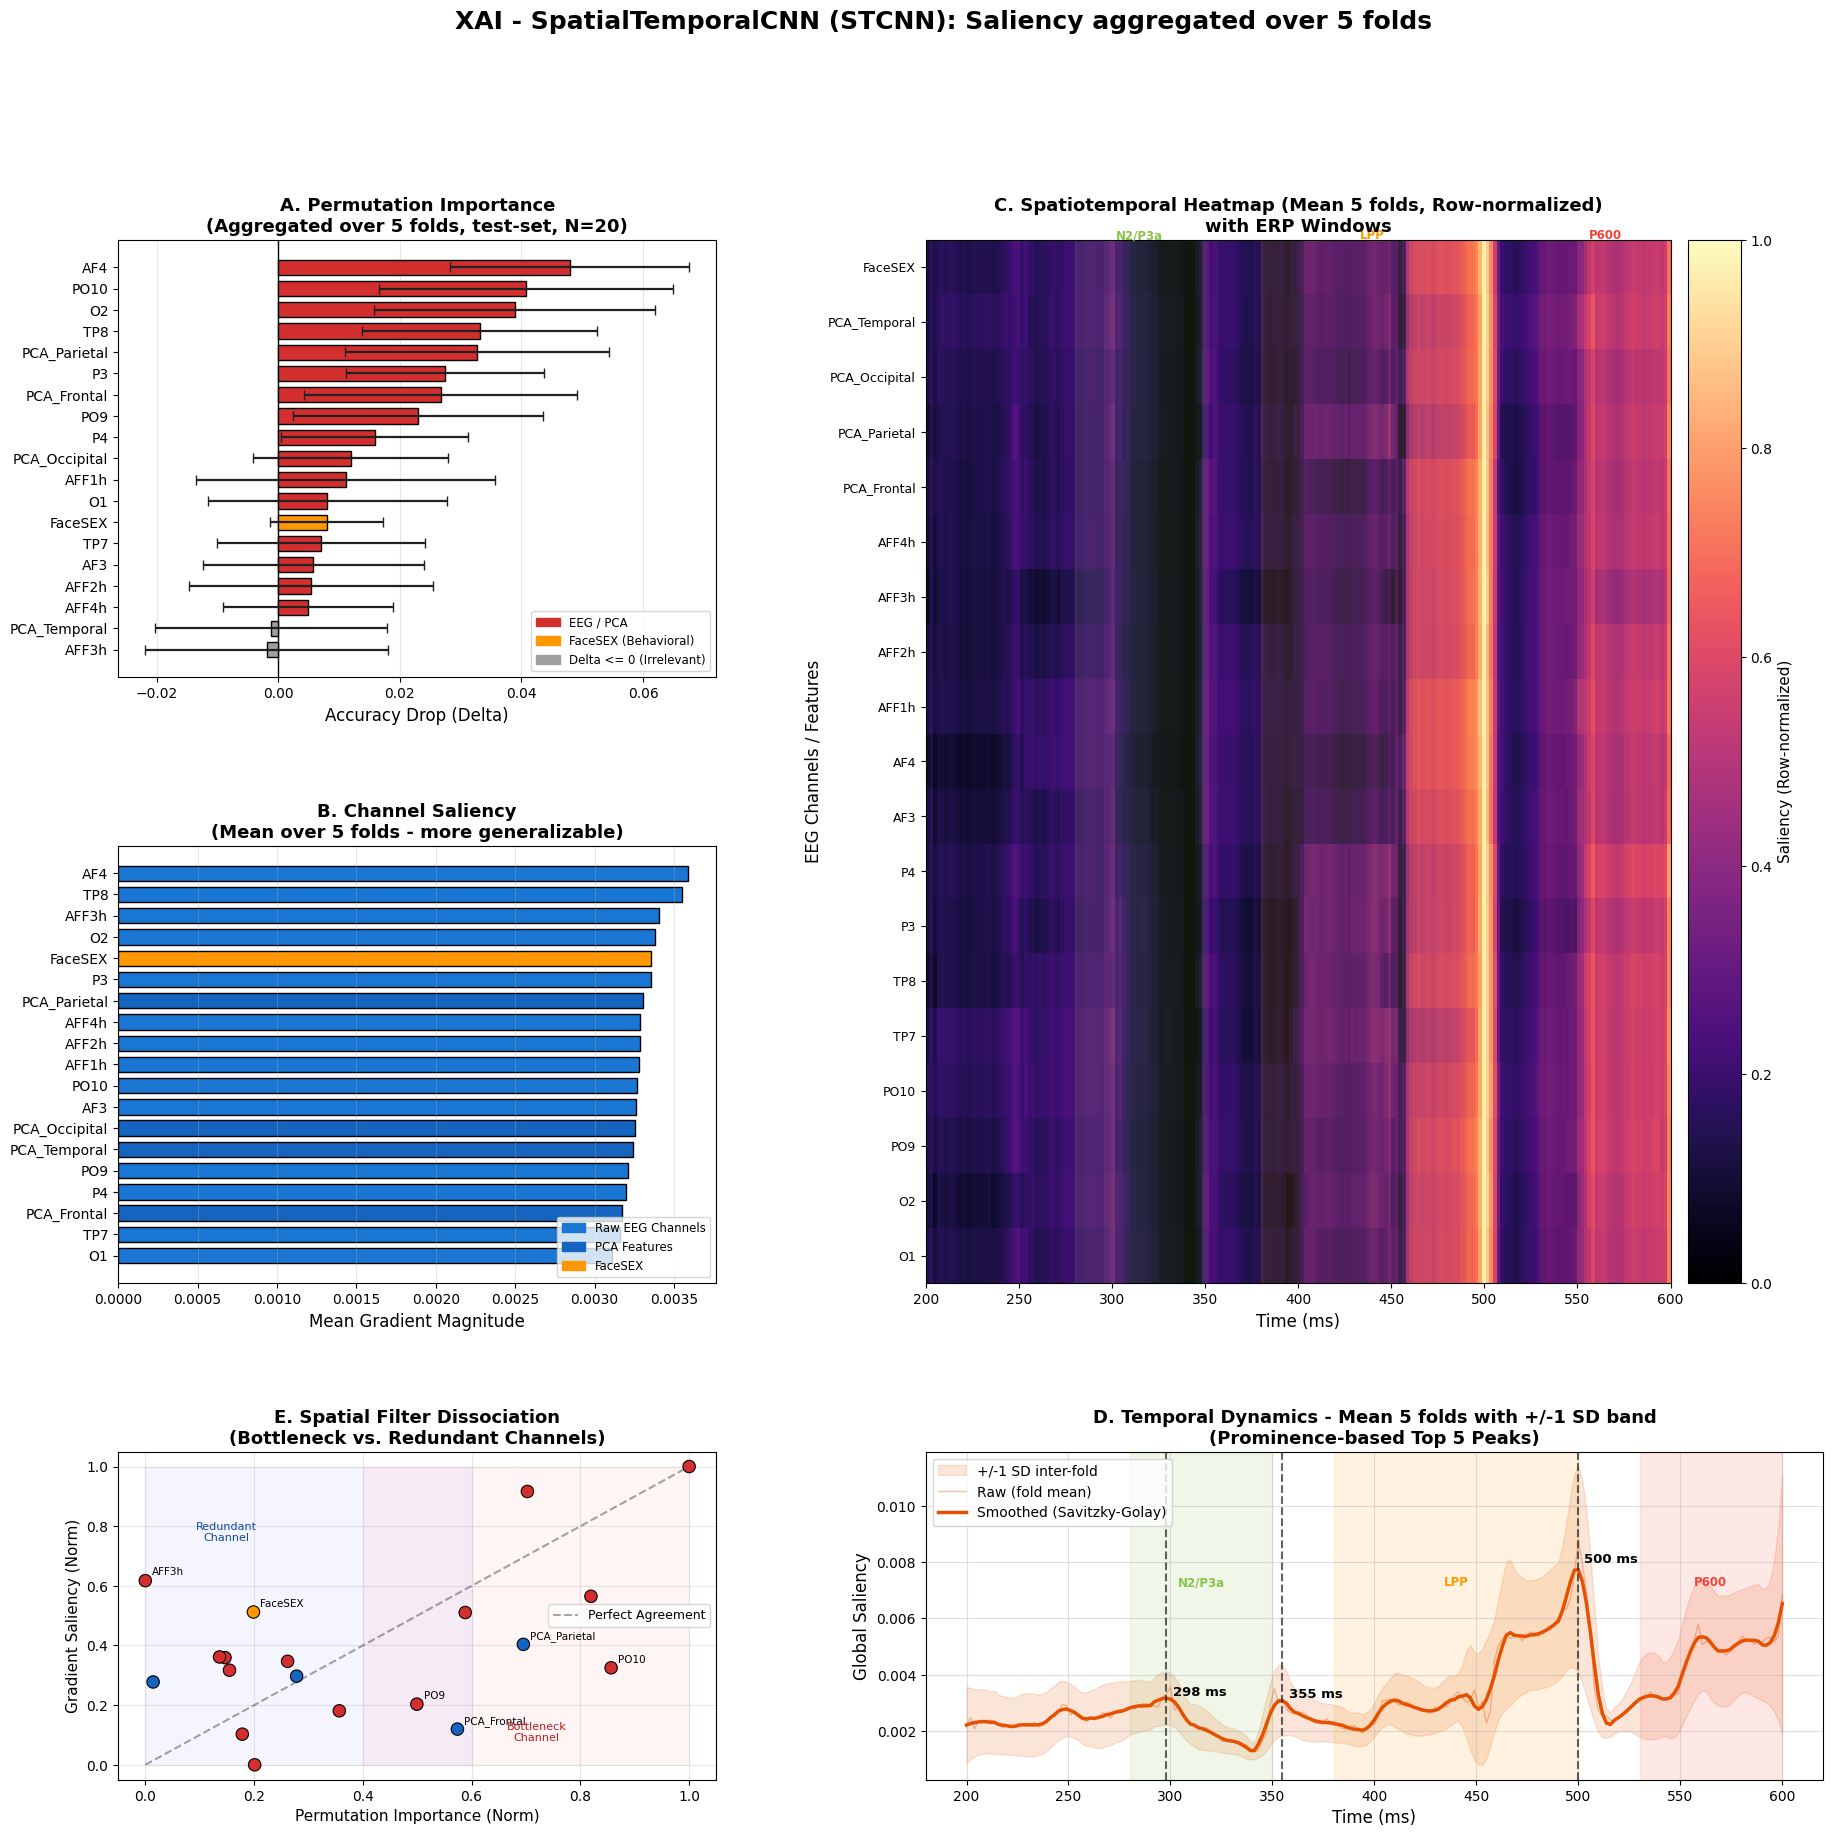

  Permutation importance: aggregated over 5 folds (test sets only)
  Saliency: mean of 5 models on their test sets - more robust and generalizable


In [32]:
channel_names = [
    'O1', 'O2', 'PO9', 'PO10', 'TP7', 'TP8', 'P3', 'P4',
    'AF3', 'AF4', 'AFF1h', 'AFF2h', 'AFF3h', 'AFF4h',
    'PCA_Frontal', 'PCA_Parietal', 'PCA_Occipital', 'PCA_Temporal', 'FaceSEX'
]
time_ms = np.linspace(200, 600, X_norm_dl.shape[2])

ERP_WINDOWS = [
    (170, 230, '#00bcd4', 'N170'),
    (280, 350, '#8bc34a', 'N2/P3a'),
    (380, 500, '#ff9800', 'LPP'),
    (530, 600, '#f44336', 'P600'),
]

# PERMUTATION IMPORTANCE (aggregated over folds, test sets only)
print("Permutation Importance aggregated over folds (test sets only)...")

N_REPEATS = 20

def get_acc(model, X_data, Y_data):
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X_data, dtype=torch.float32).to(device))
        preds = out.argmax(1).cpu().numpy()
    return accuracy_score(Y_data, preds)

base_accs = [get_acc(m, X_norm_dl[te], y_dl[te])
             for m, te in zip(fold_models, fold_te_indices)]

perm_matrix = np.zeros((len(channel_names), N_REPEATS))

for c in range(len(channel_names)):
    for r in range(N_REPEATS):
        drops = []
        for k, (model_k, te_idx) in enumerate(zip(fold_models, fold_te_indices)):
            X_te, y_te = X_norm_dl[te_idx], y_dl[te_idx]
            X_sh = X_te.copy()
            np.random.shuffle(X_sh[:, c, :])
            drops.append(base_accs[k] - get_acc(model_k, X_sh, y_te))
        perm_matrix[c, r] = np.mean(drops)

perm_importances = perm_matrix.mean(axis=1)
perm_std = perm_matrix.std(axis=1)

# SALIENCY AGGREGATED OVER ALL FOLDS
# For each fold k, model k was trained on different subjects.
# Averaging the saliency maps removes the bias of any single test subject
# and yields a map that generalizes better to the whole population.
print("Computing saliency aggregated over all folds...")

fold_saliency_maps = []

for fold_idx, (model_k, te_idx) in enumerate(zip(fold_models, fold_te_indices)):
    model_k.eval()
    X_te, y_te = X_norm_dl[te_idx], y_dl[te_idx]
    X_tensor_k = torch.tensor(X_te, dtype=torch.float32, requires_grad=True, device=device)
    Y_tensor_k = torch.tensor(y_te, device=device)

    model_k.zero_grad()
    logits_k = model_k(X_tensor_k)
    correct_logits_k = logits_k[torch.arange(len(y_te)), Y_tensor_k]
    correct_logits_k.sum().backward()

    sal_k = X_tensor_k.grad.abs().mean(dim=0).cpu().numpy()  # (channels, timesteps)
    fold_saliency_maps.append(sal_k)
    print(f"  Fold {fold_idx+1} saliency computed (test set, n={len(te_idx)}).")

# Mean over all folds: shape (channels, timesteps)
saliency_map = np.mean(fold_saliency_maps, axis=0)
saliency_std_map = np.std(fold_saliency_maps, axis=0)

channel_saliency = saliency_map.mean(axis=1)
temporal_saliency = saliency_map.mean(axis=0)

temporal_smooth = savgol_filter(temporal_saliency, window_length=11, polyorder=3)

# Row-wise normalization for the heatmap
sal_perrow = np.zeros_like(saliency_map)
for i in range(saliency_map.shape[0]):
    row = saliency_map[i]
    rmin, rmax = row.min(), row.max()
    sal_perrow[i] = (row - rmin) / (rmax - rmin + 1e-10)

peaks_idx, props = find_peaks(
    temporal_smooth,
    prominence=temporal_smooth.std() * 0.6,
    distance=int(len(time_ms) * 0.05)
)
top5 = peaks_idx[np.argsort(props['prominences'])[-5:]] if len(peaks_idx) > 5 else peaks_idx

def minmax(v):
    return (v - v.min()) / (v.max() - v.min() + 1e-10)

perm_n = minmax(perm_importances)
sal_n = minmax(channel_saliency)

def ch_color_perm(name, val):
    if name == 'FaceSEX': return '#ff9800'
    if val <= 0: return '#9e9e9e'
    return '#d32f2f'

def ch_color_sal(name):
    if name == 'FaceSEX': return '#ff9800'
    if name.startswith('PCA'): return '#1565c0'
    return '#1976d2'

def ch_color_scatter(name):
    if name == 'FaceSEX': return '#ff9800'
    if name.startswith('PCA'): return '#1565c0'
    return '#d32f2f'

print("Generating XAI figures...")

fig = plt.figure(figsize=(22, 20))
gs = gridspec.GridSpec(
    3, 2,
    height_ratios=[1.2, 1.2, 0.9],
    width_ratios=[1, 1.5],
    hspace=0.42, wspace=0.28
)

# Permutation Importance (aggregated over folds, 20 repeats)
ax0 = fig.add_subplot(gs[0, 0])
sort_idx = np.argsort(perm_importances)
s_names_a = np.array(channel_names)[sort_idx]
s_imp = perm_importances[sort_idx]
s_std = perm_std[sort_idx]
colors_a = [ch_color_perm(n, v) for n, v in zip(s_names_a, s_imp)]

ax0.barh(s_names_a, s_imp, color=colors_a, edgecolor='black', height=0.72, zorder=3)
ax0.errorbar(s_imp, np.arange(len(s_names_a)), xerr=s_std, fmt='none',
             color='#212121', capsize=3.5, linewidth=1.6, zorder=4)
ax0.axvline(0, color='black', linewidth=1)
ax0.set_xlabel('Accuracy Drop (Delta)', fontsize=12)
ax0.set_title(f'A. Permutation Importance\n(Aggregated over {N_FOLDS_DL} folds, test-set, N=20)', fontsize=13, fontweight='bold')
ax0.grid(axis='x', alpha=0.3, zorder=0)
ax0.legend(handles=[
    mpatches.Patch(color='#d32f2f', label='EEG / PCA'),
    mpatches.Patch(color='#ff9800', label='FaceSEX (Behavioral)'),
    mpatches.Patch(color='#9e9e9e', label='Delta <= 0 (Irrelevant)')
], fontsize=8.5, loc='lower right')

# Channel Saliency (mean over all folds)
ax1 = fig.add_subplot(gs[1, 0])
sort_idx_b = np.argsort(channel_saliency)
s_names_b = np.array(channel_names)[sort_idx_b]
s_sal = channel_saliency[sort_idx_b]
colors_b = [ch_color_sal(n) for n in s_names_b]

ax1.barh(s_names_b, s_sal, color=colors_b, edgecolor='black', height=0.72)
ax1.set_xlabel('Mean Gradient Magnitude', fontsize=12)
ax1.set_title(f'B. Channel Saliency\n(Mean over {N_FOLDS_DL} folds - more generalizable)', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.legend(handles=[
    mpatches.Patch(color='#1976d2', label='Raw EEG Channels'),
    mpatches.Patch(color='#1565c0', label='PCA Features'),
    mpatches.Patch(color='#ff9800', label='FaceSEX'),
], fontsize=8.5, loc='lower right')

# Scatter - Spatial Filter Dissociation
ax4 = fig.add_subplot(gs[2, 0])
sc_colors = [ch_color_scatter(n) for n in channel_names]
ax4.scatter(perm_n, sal_n, c=sc_colors, s=80, edgecolors='black', linewidths=0.8, zorder=5)

divergence = np.abs(perm_n - sal_n)
for i, (x, y_pt, name) in enumerate(zip(perm_n, sal_n, channel_names)):
    if divergence[i] > 0.28 or name == 'FaceSEX':
        ax4.annotate(name, (x, y_pt), fontsize=7.5,
                     xytext=(5, 4), textcoords='offset points',
                     arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))

ax4.plot([0, 1], [0, 1], 'k--', alpha=0.35, linewidth=1.5, label='Perfect Agreement')
ax4.fill_betweenx([0, 1], [0.4, 0.4], [1, 1], alpha=0.04, color='red')
ax4.fill_betweenx([0, 1], [0, 0], [0.6, 0.6], alpha=0.04, color='blue')
ax4.text(0.72, 0.08, 'Bottleneck\nChannel', fontsize=8, color='#b71c1c', ha='center')
ax4.text(0.15, 0.75, 'Redundant\nChannel', fontsize=8, color='#0d47a1', ha='center')

ax4.set_xlabel('Permutation Importance (Norm)', fontsize=11)
ax4.set_ylabel('Gradient Saliency (Norm)', fontsize=11)
ax4.set_title('E. Spatial Filter Dissociation\n(Bottleneck vs. Redundant Channels)', fontsize=13, fontweight='bold')
ax4.grid(alpha=0.3)
ax4.legend(fontsize=9)
ax4.set_xlim(-0.05, 1.05)
ax4.set_ylim(-0.05, 1.05)

# Spatiotemporal Heatmap (aggregated saliency)
ax2 = fig.add_subplot(gs[0:2, 1])
im = ax2.imshow(
    sal_perrow,
    aspect='auto',
    cmap='magma',
    extent=[time_ms[0], time_ms[-1], -0.5, len(channel_names) - 0.5],
    origin='lower',
    interpolation='nearest',
    vmin=0, vmax=1
)
cbar = plt.colorbar(im, ax=ax2, pad=0.02)
cbar.set_label('Saliency (Row-normalized)', fontsize=11)

ax2.set_yticks(np.arange(len(channel_names)))
ax2.set_yticklabels(channel_names, fontsize=9)
ax2.set_xlabel('Time (ms)', fontsize=12)
ax2.set_ylabel('EEG Channels / Features', fontsize=12)
ax2.set_title(f'C. Spatiotemporal Heatmap (Mean {N_FOLDS_DL} folds, Row-normalized)\nwith ERP Windows', fontsize=13, fontweight='bold')

for (t1, t2, col, label) in ERP_WINDOWS:
    if t1 >= time_ms[0]:
        ax2.axvspan(t1, t2, color=col, alpha=0.12, zorder=0)
        ax2.text((t1 + t2) / 2, len(channel_names) - 0.3, label,
                 ha='center', va='top', fontsize=8.5, color=col, fontweight='bold')

#Temporal Dynamics with inter-fold confidence band
ax3 = fig.add_subplot(gs[2, 1])

fold_temporal = np.array([s.mean(axis=0) for s in fold_saliency_maps])
fold_temp_std = fold_temporal.std(axis=0)
fold_temp_mean = fold_temporal.mean(axis=0)

ax3.fill_between(time_ms,
                 savgol_filter(fold_temp_mean - fold_temp_std, 11, 3),
                 savgol_filter(fold_temp_mean + fold_temp_std, 11, 3),
                 color='#e65100', alpha=0.15, label='+/-1 SD inter-fold')
ax3.plot(time_ms, temporal_saliency, color='#e65100', linewidth=1.0, alpha=0.35, label='Raw (fold mean)')
ax3.plot(time_ms, temporal_smooth, color='#e65100', linewidth=2.5, label='Smoothed (Savitzky-Golay)')

for (t1, t2, col, label) in ERP_WINDOWS:
    if t1 >= time_ms[0]:
        ax3.axvspan(t1, t2, color=col, alpha=0.12)
        ax3.text((t1 + t2) / 2, temporal_smooth.max() * 0.97, label,
                 ha='center', va='top', fontsize=8.5, color=col, fontweight='bold')

for p in top5:
    ax3.axvline(time_ms[p], color='#212121', linestyle='--', alpha=0.7, linewidth=1.5)
    ax3.text(time_ms[p] + 3, temporal_smooth[p] * 1.03, f"{time_ms[p]:.0f} ms",
             fontweight='bold', fontsize=9.5)

ax3.set_xlabel('Time (ms)', fontsize=12)
ax3.set_ylabel('Global Saliency', fontsize=12)
ax3.set_title(f'D. Temporal Dynamics - Mean {N_FOLDS_DL} folds with +/-1 SD band\n(Prominence-based Top 5 Peaks)', fontsize=13, fontweight='bold')
ax3.grid(alpha=0.4)
ax3.legend(fontsize=10, loc='upper left')

plt.suptitle(f"XAI - SpatialTemporalCNN (STCNN): Saliency aggregated over {N_FOLDS_DL} folds",
             fontsize=18, fontweight='bold', y=0.995)
plt.savefig('xai_analysis_v2.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"  Permutation importance: aggregated over {N_FOLDS_DL} folds (test sets only)")
print(f"  Saliency: mean of {N_FOLDS_DL} models on their test sets - more robust and generalizable")

The XAI analysis combines two complementary methods on the trained SpatialTemporalCNN: **permutation importance** (occlusion-based, run N=20 times, aggregated over all 5 folds on their respective test sets) and **gradient saliency** (averaged over all folds). The values quoted below refer to the reference figure (`xai_analysis_v2.png`) saved in this notebook. Because exact peak times and channel rankings depend on the run, the hardware (CPU/GPU) and the library versions, a re-run may shift them and should be read off the regenerated plot.

**Spatial pattern (the "where").** Permutation importance, the more reliable method for this architecture, assigns the largest accuracy drops to **AF4, PO10, O2, TP8, and PCA_Parietal** (a prominent posterior occipito-parietal cluster with a frontal contribution). Conversely, PCA_Temporal, AFF3h, AFF4h, O1 and FaceSEX rank near the bottom (or $\le 0$). The behavioral feature **FaceSEX has near-zero permutation importance ($\approx 0.008$)**, which is the key sanity check: the model is not taking a shortcut on metadata, its decision is driven by the EEG signal. Note that gradient-based channel saliency (Panel B) is relatively flat across channels, so on its own it provides weaker contrast — the permutation test is what carries the discriminative signal.

**Temporal pattern (the "when").** The temporal saliency (Panels C and D) is concentrated in the **later part of the recorded window**, not at its onset. The epoch spans 200–600 ms, so the early structural face component (N170, ~170 ms) lies essentially before the start of the window; the discriminant activity is sustained and late-stage, exhibiting prominent peaks at **~298 ms, ~355 ms, and peaking sharply at ~500 ms** with sustained activity across the late LPP / P600 window (~530–600 ms). This is consistent with a higher-order, evaluative process rather than a low-level perceptual reflex — but given the dataset size it should be read as exploratory.

**Method dissociation (the "how").** Panel E contrasts permutation importance against gradient saliency. Because the spatial information is mixed by the learnable 19×19 matrix, the two measures disagree: some channels show high gradient sensitivity but low occlusion impact (information is partly **redundant**, e.g., AFF3h, encoded elsewhere by the mixing matrix), while others show modest gradient but high occlusion impact (**bottleneck** channels like PO10, PCA_Frontal, PO9 carrying unique spatial information). The practical takeaway: in architectures with learned spatial mixing, gradient saliency alone is not sufficient to assess channel importance — the permutation test is required.

**Caveat.** With 103 epochs and a mean accuracy of 64.0%, these interpretations are exploratory. The robust, reproducible conclusions are: (1) reliance on posterior occipito-parietal channels with a frontal contribution (AF4, PO10, O2, TP8, PCA_Parietal), (2) FaceSEX is not used, (3) late rather than early temporal dynamics (LPP/P600 window), (4) permutation and gradient saliency must be cross-checked.


## 10. Results Recap

**Research question.** Can EEG signals discriminate, at the trial level, between real human faces and GAN-generated faces, a distinction on which human observers perform at or below chance behaviourally?

**Dataset.** 26 subjects, 4 conditions (50AM, 60AF = AI; 70RM, 80RF = Real), **103 epochs total** after per-(SubjectID, TargetCODE) artefact rejection (25 / 26 / 26 / 26 per condition). 14 EEG electrodes + 4 region-level PCA components (Frontal PC1=0.486, Parietal=0.471, Occipital=0.851, Temporal=0.371) + 1 FaceSEX channel → tensor **(103 × 19 × 205)**. Preprocessing: baseline correction (mean offset −0.0025 µV), 4th-order Butterworth LP 40 Hz, linear detrend, per-epoch baseline subtraction, artefact rejection (80 µV threshold, max 2 bad channels). ML section further applies intra-subject z-score and excludes subject 01 (incomplete condition set) → **100 trials [50 AI / 50 Real], 25 subjects**.

**Method 1 — Encoding/Decoding (mass-univariate, 220–500 ms, 18 ch).** Ridge encoding: best α=100, training R²=0.0052, best CV R² per channel=−0.0155 (ch 17). ANOVA F-map: diffuse, max F=8.57 (ch 8). SDT AUC map: uniformly ~0.500 (best ch 1 AUC=0.500). Binary logistic decoder (AI vs Real): accuracy **0.623 ± 0.106** (chance=0.50). No single channel or timepoint carries a detectable linear class signal well above chance.

**Method 2 — Classical ML (8 models, nested CV, 100 trials).** Full nested CV execution: outer $5 \times 5$ StratifiedGroupKFold (25 outer folds), inner GroupShuffleSplit (5 splits, 20% holdout, $n\text{_iter}=30$). Full pipeline: intra-subject z-score → SelectKBest(ANOVA-F) → classifier. Results (25 outer folds):

| Model | ACC | macro-F1 | ROC-AUC |
|---|---|---|---|
| **LDA** | **0.700 (var 0.0048)** | **0.698 (var 0.0048)** | **0.783 (var 0.0090)** |
| LinearSVC_Cal | 0.700 (var 0.0062) | 0.698 (var 0.0064) | 0.778 (var 0.0098) |
| LinearSVC | 0.696 (var 0.0070) | 0.695 (var 0.0070) | 0.778 (var 0.0107) |
| LogReg_EN | 0.696 (var 0.0054) | 0.694 (var 0.0055) | 0.777 (var 0.0097) |
| LogReg_L1 | 0.694 (var 0.0075) | 0.692 (var 0.0076) | 0.778 (var 0.0121) |
| SGD | 0.688 (var 0.0099) | 0.678 (var 0.0126) | 0.778 (var 0.0131) |
| XGBoost | 0.678 (var 0.0092) | 0.673 (var 0.0101) | 0.774 (var 0.0122) |
| Dummy | 0.500 (var 0.0000) | 0.333 (var 0.0000) | 0.500 (var 0.0000) |

Stage 2 focused search on LDA ($n\text{_iter}=80$, 25 outer folds) → ACC=**0.720 (var 0.0062)**, macro-F1=**0.718**, ROC-AUC=**0.780**, **adopted** (improved over Stage 1). Most frequent config: `clf__shrinkage=0.05`, `clf__solver='lsqr'`, `scaler=RobustScaler()`, `selector__k=10`. Permutation test (LDA, $n=1000$ trial-level shuffles): observed ACC=**0.750**, null mean=0.491 (var 0.0038), **p=0.0010**; MCC=**+0.500** (null=−0.018), **p=0.0010** → decoding ABOVE chance. Wilcoxon signed-rank test (Bonferroni-corrected, 25 folds): LDA significantly beats Dummy ($p_{\text{Bonf}}=0.0001$), while pairwise differences among top linear models (LinearSVC_Cal $p_{\text{raw}}=0.0845$, LinearSVC $p_{\text{raw}}=0.0523$, LogReg_EN $p_{\text{raw}}=0.0557$, LogReg_L1 $p_{\text{raw}}=0.0394$, SGD $p_{\text{raw}}=0.0494$, XGBoost $p_{\text{raw}}=0.0318$) are not statistically significant after Bonferroni correction.

**Method 3 — SpatialTemporalCNN (103 epochs, 5-fold CV).** Architecture: learned spatial adjacency (19×19) → Conv1d temporal filters → adaptive mean pooling → FC (2 classes) tuned with Optuna CMA-ES. Per-fold: 65.2% / 60.0% / 55.0% / 70.0% / 70.0% (AUC: 0.652 / 0.570 / 0.750 / 0.680 / 0.700). **Mean: 64.0% ± 5.8%, Mean AUC = 0.670**. Binomial test: 66/103 correct, **p=0.0028 — significant ($p < 0.05$)**. Classification report: AI precision=0.63, recall=0.65, F1=0.64 (support=51); Human precision=0.65, recall=0.63, F1=0.64 (support=52); macro-F1=0.64 (accuracy=0.64). XAI (permutation importance + gradient saliency): most informative channels are **AF4, PO10, O2, TP8, PCA_Parietal** (posterior occipito-parietal cluster with a frontal contribution); FaceSEX ≈ 0.008 (sanity check passed); peak saliency at **~500 ms (late LPP / P600 window, ~530–600 ms)**.


## 11. Conclusions

The three methods converge on a coherent picture, with important nuances. The encoding/decoding analysis establishes that the AI/Real signal is **not linearly separable at the univariate level**. No single electrode or timepoint has a detectable class-specific response at this epoch count (binary decoding accuracy 0.623 ± 0.106, barely above chance; best channel AUC=0.500; best CV R²=−0.0155), which is the expected outcome for a distributed higher-order signal given the limited number of condition-averaged epochs (103).

Classical ML confirms that the signal **exists at the multivariate level**: jointly exploiting all 18 channels across 103 decimated timepoints, Linear Discriminant Analysis (LDA) achieves ACC=0.700 in Stage 1 and ACC=0.720 (ROC-AUC=0.780) after Stage 2 focused search (adopted). The permutation test confirms the effect is robustly above chance (observed accuracy=0.750, p=0.0010, MCC=+0.500 vs null=−0.018, n=1000 shuffles). The Wilcoxon comparison across models confirms that LDA is significantly superior to the Dummy baseline ($p_{\text{Bonf}}=0.0001$), while performing on par with regularized linear classifiers (LinearSVC, Calibrated LinearSVC, Logistic Regression L1/ElasticNet).

The STCNN achieves a mean accuracy of **64.0% ± 5.8% (Mean AUC=0.670)** across 5-fold cross-validation (fold range 55–70%). The binomial test against chance (66/103 correct, **p=0.0028**) is **statistically significant** at the 5% level. Among the methods, the STCNN provides deep architectural insights and interpretable spatial–temporal attribution: the XAI output identifies a **posterior cluster with a frontal contribution (AF4 / PO10 / O2 / TP8 / PCA_Parietal) most salient around ~500 ms (late LPP / P600 window)**, consistent with late evaluative face processing rather than early low-level visual discrimination. Balanced precision and recall (0.64 F1 for both AI and Real) confirm the result is not driven by class imbalance or an asymmetric decision boundary. FaceSEX permutation importance ($\approx 0.008$) confirms the model exploits EEG signal, not stimulus metadata.

The overall effect size is solid (ML permutation: ~25 pp above chance, p=0.0010; DL binomial: ~14 pp above chance, p=0.0028), consistent with EEG decoding studies on subtle within-category stimulus differences at low trial counts. The core claim — that EEG encodes an AI/Real distinction that behaviour does not explicitly report — is supported by both the classical ML pipeline (p=0.0010, full 5×5 nested CV) and the deep learning model (p=0.0028), and is spatially localised to posterior occipito-parietal channels (with a frontal contribution) with late temporal dynamics (LPP/P600 window).


**Drawbacks.**

- **Sample size.** ~4 condition-averaged trials/subject (100 total: 50 AI / 50 Real across 25 subjects, ~2 per class per subject) is the main bottleneck. Each outer CV fold contains only ~20 test trials, making fold-level estimates variable (STCNN fold range: 55–70%) and effect sizes wide. All results should be treated as robust preliminary evidence.
- **Nested CV variance.** Despite full 5×5 repeated nested CV and 1000 permutations, the limited sample size per subject means confidence intervals remain moderately wide.
- **No behavioural baseline.** The notebook does not compare per-trial classifier confidence against the same subjects' actual AI/Real judgements, which would be the most direct test of the implicit-encoding hypothesis.

**Future work.**

1. Scale to larger multi-subject cohorts and explore fine-grained trial-by-trial decoding rather than condition-averaged ERPs.
2. Collect more trials (≥10 per subject per condition). This is the single most impactful improvement for both accuracy and statistical power.
3. Compare per-trial neural decoding confidence against behavioural AI/Real judgements on the same stimuli.
